In [ ]:
# ============================================================
# TFM – Análisis Exploratorio de Datos (EDA)
# Dataset Poses baokhang9826_YOLO
# ============================================================
# Antes de ejecutar este notebook:
#   Runtime → Change runtime type → GPU (T4 / A100) + High-RAM
# ============================================================

In [1]:
# ============================================================
# CELDA 1 – Montar Drive y verificar GPU / RAM disponible
# ============================================================

import subprocess
import sys
import os

# ── 1. Montar Google Drive ──────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# ── 2. Verificar GPU ────────────────────────────────────────
print("=" * 55)
print("🖥️  VERIFICACIÓN DE HARDWARE")
print("=" * 55)

try:
    gpu_info = subprocess.run(
        [
            'nvidia-smi',
            '--query-gpu=name,memory.total,memory.free,utilization.gpu',
            '--format=csv,noheader,nounits'
        ],
        capture_output=True,
        text=True,
        timeout=10
    )

    if gpu_info.returncode == 0 and gpu_info.stdout.strip():
        for line in gpu_info.stdout.strip().split('\n'):
            parts = [p.strip() for p in line.split(',')]

            print(f"  ✅ GPU    : {parts[0]}")
            print(f"  📦 VRAM   : {int(parts[1]):,} MB totales  |  {int(parts[2]):,} MB libres")
            print(f"  ⚙️  Uso GPU: {parts[3]}%")
    else:
        print("  ⚠️  No se detectó GPU.")
        print("     Ve a Runtime → Change runtime type → GPU.")

except Exception as e:
    print(f"  ⚠️  Error al consultar GPU: {e}")

# ── 3. Verificar RAM del sistema ────────────────────────────
try:
    ram_info = subprocess.run(
        ['cat', '/proc/meminfo'],
        capture_output=True,
        text=True
    )

    lines = ram_info.stdout.split('\n')

    mem_total_kb = int([l for l in lines if l.startswith('MemTotal')][0].split()[1])
    mem_avail_kb = int([l for l in lines if l.startswith('MemAvailable')][0].split()[1])

    print(f"  💾 RAM    : {mem_total_kb / 1024**2:.1f} GB totales  |  {mem_avail_kb / 1024**2:.1f} GB disponibles")

    if mem_total_kb / 1024**2 >= 50:
        print("  ✅ High-RAM activo ≥ 50 GB")
    else:
        print("  ⚠️  RAM estándar aproximada.")
        print("     Para High-RAM ve a Runtime → Change runtime type.")

except Exception as e:
    print(f"  ⚠️  Error al leer RAM: {e}")

# ── 4. Verificar Python, PyTorch y CUDA ─────────────────────
try:
    import torch

    print(f"  🐍 Python : {sys.version.split()[0]}")

    if torch.cuda.is_available():
        print(f"  🔥 CUDA   : {torch.version.cuda}  |  PyTorch {torch.__version__}")
        print(f"  🎯 Device : {torch.cuda.get_device_name(0)}")
    else:
        print("  ⚠️  PyTorch no detecta CUDA.")

except Exception as e:
    print(f"  ⚠️  Error al verificar PyTorch/CUDA: {e}")

print("=" * 55)

Mounted at /content/drive
🖥️  VERIFICACIÓN DE HARDWARE
  ✅ GPU    : Tesla T4
  📦 VRAM   : 15,360 MB totales  |  14,913 MB libres
  ⚙️  Uso GPU: 0%
  💾 RAM    : 51.0 GB totales  |  49.4 GB disponibles
  ✅ High-RAM activo ≥ 50 GB
  🐍 Python : 3.12.13
  🔥 CUDA   : 12.8  |  PyTorch 2.11.0+cu128
  🎯 Device : Tesla T4


In [2]:
# ============================================================
# CELDA 2 – Descomprimir baokhang9826_YOLO.zip de forma permanente
# ============================================================

from pathlib import Path
import zipfile
import shutil
import time
import os

from google.colab import drive

# ── 0. Montar Drive ─────────────────────────────────────────
drive.mount("/content/drive", force_remount=False)

# ── 1. Rutas del dataset ────────────────────────────────────

ZIP_PATH = Path("/content/drive/MyDrive/TFM/baokhang9826_YOLO.zip")

# Carpeta raíz donde se guardarán los datasets descomprimidos
DATASETS_DIR = Path("/content/drive/MyDrive/TFM/datasets")

# Nombre permanente del dataset
DATASET_NAME = "baokhang9826_YOLO"

# Carpeta final del dataset
BASE = DATASETS_DIR / DATASET_NAME

# Carpeta temporal controlada
TMP_EXTRACT = DATASETS_DIR / f"_tmp_extract_{DATASET_NAME}"

# Archivo marcador para no volver a descomprimir si ya quedó listo
MARKER = BASE / ".extract_complete"

print("=" * 70)
print(f"📦 PREPARANDO DATASET {DATASET_NAME}")
print("=" * 70)

# ── 2. Validaciones iniciales ───────────────────────────────

if not ZIP_PATH.exists():
    raise FileNotFoundError(
        f"No se encontró el ZIP en la ruta esperada:\n{ZIP_PATH}\n\n"
        "Verifica que el archivo esté en MyDrive/TFM y que el nombre sea exactamente:\n"
        "baokhang9826_YOLO.zip"
    )

DATASETS_DIR.mkdir(parents=True, exist_ok=True)

print(f"📄 ZIP origen        : {ZIP_PATH}")
print(f"📁 Carpeta destino   : {BASE}")
print(f"📁 Carpeta temporal  : {TMP_EXTRACT}")

# ── 3. Evitar descomprimir si ya existe ─────────────────────

if MARKER.exists():
    print("\n✅ El dataset ya fue descomprimido previamente.")
    print("ℹ️ No se volverá a descomprimir para evitar duplicados.")
    print(f"📁 Ruta permanente: {BASE}")

else:
    print("\n⚠️ El dataset aún no está preparado.")
    print("📂 Se descomprimirá una sola vez en Google Drive.")

    # Limpiar carpeta temporal de una ejecución fallida anterior
    if TMP_EXTRACT.exists():
        print(f"🧹 Eliminando carpeta temporal previa: {TMP_EXTRACT}")
        shutil.rmtree(TMP_EXTRACT)

    TMP_EXTRACT.mkdir(parents=True, exist_ok=True)

    # Verificar que el ZIP no esté corrupto
    print("\n🔎 Verificando integridad del ZIP...")

    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        corrupt_file = z.testzip()

        if corrupt_file is not None:
            raise zipfile.BadZipFile(
                f"El ZIP parece estar corrupto. Primer archivo con problema: {corrupt_file}"
            )

        print("✅ ZIP válido.")

        # Descomprimir en carpeta temporal
        print("\n📦 Descomprimiendo ZIP...")
        t0 = time.time()

        z.extractall(TMP_EXTRACT)

    elapsed = time.time() - t0
    print(f"✅ ZIP descomprimido temporalmente en {elapsed / 60:.2f} minutos")

    # Si existe una carpeta destino incompleta, se elimina
    if BASE.exists():
        print(f"🧹 Eliminando carpeta destino incompleta anterior: {BASE}")
        shutil.rmtree(BASE)

    # Mover temporal a carpeta definitiva
    TMP_EXTRACT.rename(BASE)

    # Crear marcador de extracción completa
    MARKER.touch()

    print("\n✅ Dataset guardado permanentemente en Drive.")
    print(f"📁 Ruta final: {BASE}")

# ── 4. Inspección básica del contenido ──────────────────────

print("\n" + "=" * 70)
print("🔍 INSPECCIÓN INICIAL DEL DATASET")
print("=" * 70)

print("\n📂 Primer nivel dentro del dataset:")

items_primer_nivel = sorted(BASE.iterdir())

if not items_primer_nivel:
    print("  ⚠️ La carpeta del dataset está vacía.")
else:
    for item in items_primer_nivel:
        tipo = "carpeta" if item.is_dir() else "archivo"
        print(f"  - {item.name} [{tipo}]")

print("\n📂 Árbol de carpetas hasta profundidad 3:")

carpetas = [p for p in sorted(BASE.rglob("*")) if p.is_dir()]

if not carpetas:
    print("  ⚠️ No se encontraron carpetas internas.")
else:
    for p in carpetas:
        rel = p.relative_to(BASE)
        depth = len(rel.parts)

        if depth <= 3:
            print("  " * depth + f"📁 {p.name}")

# ── 5. Conteo rápido de tipos de archivos ───────────────────

VIDEO_EXTS = {".avi", ".mp4", ".mov", ".mkv", ".mpg", ".mpeg"}
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}
ANNOT_EXTS = {".txt", ".xml", ".csv", ".json", ".xlsx", ".xls", ".yaml", ".yml"}

videos = [
    p for p in BASE.rglob("*")
    if p.is_file() and p.suffix.lower() in VIDEO_EXTS
]

imagenes = [
    p for p in BASE.rglob("*")
    if p.is_file() and p.suffix.lower() in IMG_EXTS
]

anotaciones = [
    p for p in BASE.rglob("*")
    if p.is_file() and p.suffix.lower() in ANNOT_EXTS
]

print("\n" + "=" * 70)
print("📊 RESUMEN DE ARCHIVOS")
print("=" * 70)

print(f"🎥 Videos encontrados      : {len(videos)}")
print(f"🖼️ Imágenes encontradas    : {len(imagenes)}")
print(f"📝 Anotaciones encontradas : {len(anotaciones)}")

print("\n📌 Ejemplos de archivos encontrados:")

print("\n🎥 Videos:")
if videos:
    for p in videos[:5]:
        print(f"  - {p.relative_to(BASE)}")
else:
    print("  - No se encontraron videos.")

print("\n🖼️ Imágenes:")
if imagenes:
    for p in imagenes[:5]:
        print(f"  - {p.relative_to(BASE)}")
else:
    print("  - No se encontraron imágenes.")

print("\n📝 Anotaciones:")
if anotaciones:
    for p in anotaciones[:5]:
        print(f"  - {p.relative_to(BASE)}")
else:
    print("  - No se encontraron anotaciones.")

# ── 6. Ruta final útil para usar en las siguientes celdas ───

print("\n" + "=" * 70)
print("✅ RUTA FINAL DEL DATASET")
print("=" * 70)
print(BASE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📦 PREPARANDO DATASET baokhang9826_YOLO
📄 ZIP origen        : /content/drive/MyDrive/TFM/baokhang9826_YOLO.zip
📁 Carpeta destino   : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO
📁 Carpeta temporal  : /content/drive/MyDrive/TFM/datasets/_tmp_extract_baokhang9826_YOLO

⚠️ El dataset aún no está preparado.
📂 Se descomprimirá una sola vez en Google Drive.

🔎 Verificando integridad del ZIP...
✅ ZIP válido.

📦 Descomprimiendo ZIP...
✅ ZIP descomprimido temporalmente en 9.85 minutos

✅ Dataset guardado permanentemente en Drive.
📁 Ruta final: /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO

🔍 INSPECCIÓN INICIAL DEL DATASET

📂 Primer nivel dentro del dataset:
  - .extract_complete [archivo]
  - data [carpeta]

📂 Árbol de carpetas hasta profundidad 3:
  📁 data
    📁 raw
      📁 train
      📁 val
    📁 test
      📁 fall
      📁 non_fall
      📁 video
    📁

In [3]:
# ============================================================
# CELDA 3 – Librerías, rutas del dataset baokhang9826_YOLO
#           y verificación / ajuste de data.yaml
# ============================================================

import os
import time
import yaml
import shutil
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.family": "DejaVu Sans",
})

# ── 1. Rutas reales según tu descompresión ───────────────────

BASE = Path("/content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO")

# Esta es la carpeta que contiene train/, val/, test/, raw/ y data.yaml
YOLO = BASE / "data"

YAML_PATH = YOLO / "data.yaml"

SPLITS = ["train", "val"]

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Solo se usa si data.yaml no trae clases
CLASES_DEFAULT = ["fall", "non_fall"]

print("=" * 70)
print("📌 CONFIGURACIÓN DEL DATASET baokhang9826_YOLO")
print("=" * 70)

print(f"📁 BASE      : {BASE}")
print(f"📁 YOLO root : {YOLO}")
print(f"📄 data.yaml : {YAML_PATH}")

# ── 2. Validaciones básicas ─────────────────────────────────

if not BASE.exists():
    raise FileNotFoundError(f"No existe la carpeta BASE:\n{BASE}")

if not YOLO.exists():
    raise FileNotFoundError(
        f"No existe la carpeta YOLO esperada:\n{YOLO}\n\n"
        "Revisa que el ZIP se haya descomprimido correctamente."
    )

for split in SPLITS:
    img_dir = YOLO / split / "images"
    lbl_dir = YOLO / split / "labels"

    if not img_dir.exists():
        print(f"⚠️ No existe carpeta de imágenes para {split}: {img_dir}")

    if not lbl_dir.exists():
        print(f"⚠️ No existe carpeta de labels para {split}: {lbl_dir}")

# ── 3. Función para normalizar nombres de clases ─────────────

def normalizar_names(names):
    """
    Acepta names como lista o diccionario.
    Devuelve lista ordenada de nombres de clases.
    """

    if names is None:
        return None

    if isinstance(names, list):
        return names

    if isinstance(names, dict):
        try:
            return [names[k] for k in sorted(names, key=lambda x: int(x))]
        except Exception:
            return list(names.values())

    return None

# ── 4. Leer data.yaml existente o crear uno nuevo ────────────

if YAML_PATH.exists():
    print("\n✅ data.yaml encontrado.")

    with open(YAML_PATH, "r", encoding="utf-8") as f:
        ydata_original = yaml.safe_load(f)

    if ydata_original is None:
        ydata_original = {}

    CLASS_NAMES = normalizar_names(ydata_original.get("names"))

    if CLASS_NAMES is None:
        CLASS_NAMES = CLASES_DEFAULT
        print("⚠️ data.yaml existe, pero no trae nombres de clases válidos.")
        print(f"   Usando clases por defecto: {CLASS_NAMES}")
    else:
        print(f"✅ Clases leídas desde data.yaml: {CLASS_NAMES}")

else:
    print("\n⚠️ data.yaml no existe.")
    print("   Se creará uno nuevo usando clases por defecto.")

    ydata_original = {}
    CLASS_NAMES = CLASES_DEFAULT

NUM_CLASSES = len(CLASS_NAMES)

# ── 5. Detectar si existe test en formato YOLO ───────────────

test_images = YOLO / "test" / "images"
test_labels = YOLO / "test" / "labels"

TIENE_TEST_YOLO = test_images.exists() and test_labels.exists()

if TIENE_TEST_YOLO:
    print("\n✅ Test YOLO detectado:")
    print(f"   images: {test_images}")
    print(f"   labels: {test_labels}")
else:
    print("\n⚠️ No se detectó test en formato YOLO estándar.")
    print("   Esto no impide entrenar, porque YOLO puede usar train y val.")
    print("   En tu dataset el test parece estar separado como videos o carpetas fall/non_fall.")

# ── 6. Construir data.yaml correcto para Colab ───────────────

data_yaml_content = {
    "path": str(YOLO),
    "train": "train/images",
    "val": "val/images",
    "nc": NUM_CLASSES,
    "names": CLASS_NAMES,
}

if TIENE_TEST_YOLO:
    data_yaml_content["test"] = "test/images"

# ── 7. Crear o actualizar data.yaml ──────────────────────────

actualizar_yaml = True

if YAML_PATH.exists():
    # Comparamos solo las claves importantes
    diferencias = []

    for k, v in data_yaml_content.items():
        if ydata_original.get(k) != v:
            diferencias.append(k)

    if diferencias:
        print("\n⚠️ data.yaml necesita ajustes para este entorno de Colab.")
        print(f"   Campos a corregir: {diferencias}")

        backup_path = YOLO / f"data_original_backup_{time.strftime('%Y%m%d_%H%M%S')}.yaml"
        shutil.copy2(YAML_PATH, backup_path)

        print(f"📄 Copia de seguridad creada en:")
        print(f"   {backup_path}")
    else:
        actualizar_yaml = False
        print("\n✅ data.yaml ya está correctamente configurado.")
else:
    print("\n📄 Se creará data.yaml desde cero.")

if actualizar_yaml:
    with open(YAML_PATH, "w", encoding="utf-8") as f:
        yaml.dump(
            data_yaml_content,
            f,
            default_flow_style=False,
            allow_unicode=True,
            sort_keys=False
        )

    print("\n✅ data.yaml actualizado correctamente.")

# ── 8. Mostrar contenido final de data.yaml ──────────────────

print("\n" + "=" * 70)
print("📄 CONTENIDO FINAL DE data.yaml")
print("=" * 70)

with open(YAML_PATH, "r", encoding="utf-8") as f:
    contenido_final = yaml.safe_load(f)

for k, v in contenido_final.items():
    print(f"{k}: {v}")

# ── 9. Verificación de carpetas YOLO ─────────────────────────

print("\n" + "=" * 70)
print("🔍 VERIFICACIÓN DE ESTRUCTURA YOLO")
print("=" * 70)

for split in SPLITS:
    img_dir = YOLO / split / "images"
    lbl_dir = YOLO / split / "labels"

    img_ok = img_dir.exists()
    lbl_ok = lbl_dir.exists()

    print(f"\n📂 Split: {split}")
    print(f"   images: {'✅' if img_ok else '❌'} {img_dir}")
    print(f"   labels: {'✅' if lbl_ok else '❌'} {lbl_dir}")

# ── 10. Conteo de imágenes y etiquetas ───────────────────────

def listar_imagenes(carpeta):
    if not carpeta.exists():
        return []
    return sorted([
        p for p in carpeta.rglob("*")
        if p.is_file() and p.suffix.lower() in IMG_EXTS
    ])

def listar_labels(carpeta):
    if not carpeta.exists():
        return []
    return sorted([
        p for p in carpeta.rglob("*.txt")
        if p.is_file()
    ])

print("\n" + "=" * 70)
print("📊 RESUMEN POR SPLIT")
print("=" * 70)

resumen = []

for split in SPLITS:
    img_dir = YOLO / split / "images"
    lbl_dir = YOLO / split / "labels"

    imagenes = listar_imagenes(img_dir)
    labels = listar_labels(lbl_dir)

    stems_img = {p.stem for p in imagenes}
    stems_lbl = {p.stem for p in labels}

    sin_label = stems_img - stems_lbl
    sin_imagen = stems_lbl - stems_img

    resumen.append({
        "split": split,
        "imagenes": len(imagenes),
        "labels": len(labels),
        "imagenes_sin_label": len(sin_label),
        "labels_sin_imagen": len(sin_imagen),
    })

    print(f"\n📂 {split}")
    print(f"   🖼️ Imágenes           : {len(imagenes)}")
    print(f"   📝 Labels             : {len(labels)}")
    print(f"   ⚠️ Imágenes sin label : {len(sin_label)}")
    print(f"   ⚠️ Labels sin imagen  : {len(sin_imagen)}")

    if len(sin_label) > 0:
        print("   Ejemplos imágenes sin label:")
        for s in list(sorted(sin_label))[:5]:
            print(f"      - {s}")

    if len(sin_imagen) > 0:
        print("   Ejemplos labels sin imagen:")
        for s in list(sorted(sin_imagen))[:5]:
            print(f"      - {s}")

df_resumen = pd.DataFrame(resumen)

print("\n📌 Tabla resumen:")
display(df_resumen)

# ── 11. Revisión rápida del contenido de los .txt YOLO ───────

print("\n" + "=" * 70)
print("🧪 VALIDACIÓN BÁSICA DE LABELS YOLO")
print("=" * 70)

conteo_clases = Counter()
labels_vacios = 0
lineas_mal_formadas = 0
boxes_fuera_rango = 0
total_boxes = 0

ejemplos_mal_formados = []
ejemplos_fuera_rango = []

for split in SPLITS:
    lbl_dir = YOLO / split / "labels"
    label_files = listar_labels(lbl_dir)

    for label_path in label_files:
        with open(label_path, "r", encoding="utf-8", errors="ignore") as f:
            lines = [ln.strip() for ln in f.readlines() if ln.strip()]

        if len(lines) == 0:
            labels_vacios += 1
            continue

        for line in lines:
            parts = line.split()

            if len(parts) != 5:
                lineas_mal_formadas += 1
                if len(ejemplos_mal_formados) < 5:
                    ejemplos_mal_formados.append((label_path, line))
                continue

            try:
                class_id = int(float(parts[0]))
                x, y, w, h = map(float, parts[1:])

                total_boxes += 1
                conteo_clases[class_id] += 1

                if not all(0 <= v <= 1 for v in [x, y, w, h]):
                    boxes_fuera_rango += 1
                    if len(ejemplos_fuera_rango) < 5:
                        ejemplos_fuera_rango.append((label_path, line))

            except Exception:
                lineas_mal_formadas += 1
                if len(ejemplos_mal_formados) < 5:
                    ejemplos_mal_formados.append((label_path, line))

print(f"📦 Total de bounding boxes : {total_boxes}")
print(f"📝 Labels vacíos           : {labels_vacios}")
print(f"⚠️ Líneas mal formadas     : {lineas_mal_formadas}")
print(f"⚠️ Boxes fuera de rango    : {boxes_fuera_rango}")

print("\n📊 Conteo por class_id:")
for class_id, count in sorted(conteo_clases.items()):
    nombre = CLASS_NAMES[class_id] if 0 <= class_id < len(CLASS_NAMES) else "CLASE_DESCONOCIDA"
    print(f"   Clase {class_id} ({nombre}): {count}")

if ejemplos_mal_formados:
    print("\n⚠️ Ejemplos de líneas mal formadas:")
    for path, line in ejemplos_mal_formados:
        print(f"   {path.relative_to(YOLO)} → {line}")

if ejemplos_fuera_rango:
    print("\n⚠️ Ejemplos de boxes fuera de rango:")
    for path, line in ejemplos_fuera_rango:
        print(f"   {path.relative_to(YOLO)} → {line}")

# ── 12. Ruta final para entrenamiento ────────────────────────

print("\n" + "=" * 70)
print("✅ DATASET LISTO PARA ENTRENAMIENTO YOLO")
print("=" * 70)

print(f"📄 Usa esta ruta en model.train():")
print(f"   {YAML_PATH}")

DATA_YAML = YAML_PATH

📌 CONFIGURACIÓN DEL DATASET baokhang9826_YOLO
📁 BASE      : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO
📁 YOLO root : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/data
📄 data.yaml : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/data/data.yaml

✅ data.yaml encontrado.
✅ Clases leídas desde data.yaml: ['fall', 'non_fall']

⚠️ No se detectó test en formato YOLO estándar.
   Esto no impide entrenar, porque YOLO puede usar train y val.
   En tu dataset el test parece estar separado como videos o carpetas fall/non_fall.

⚠️ data.yaml necesita ajustes para este entorno de Colab.
   Campos a corregir: ['path']
📄 Copia de seguridad creada en:
   /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/data/data_original_backup_20260611_033808.yaml

✅ data.yaml actualizado correctamente.

📄 CONTENIDO FINAL DE data.yaml
path: /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/data
train: train/images
val: val/images
nc: 2
names: ['fall', 'non_fall']

🔍 VERIFICACIÓN DE E

,split,imagenes,labels,imagenes_sin_label,labels_sin_imagen
0,train,5504,4856,648,0
1,val,1175,1156,19,0



🧪 VALIDACIÓN BÁSICA DE LABELS YOLO
📦 Total de bounding boxes : 6090
📝 Labels vacíos           : 0
⚠️ Líneas mal formadas     : 0
⚠️ Boxes fuera de rango    : 0

📊 Conteo por class_id:
   Clase 0 (fall): 2220
   Clase 1 (non_fall): 3870

✅ DATASET LISTO PARA ENTRENAMIENTO YOLO
📄 Usa esta ruta en model.train():
   /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/data/data.yaml


📊 CONTEO DE ARCHIVOS POR SPLIT
📁 BASE : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO
📁 YOLO : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/data
  TRAIN  │ ✅ Imágenes:  5,504 │ ✅ Labels:  4,856
  VAL    │ ✅ Imágenes:  1,175 │ ✅ Labels:  1,156
  TOTAL  │    Imágenes:  6,679 │    Labels:  6,012

📌 Tabla resumen:


,split,imagenes,labels,diferencia_img_label,ruta_imagenes,ruta_labels
0,train,5504,4856,648,/content/drive/MyDrive/TFM/datasets/baokhang98...,/content/drive/MyDrive/TFM/datasets/baokhang98...
1,val,1175,1156,19,/content/drive/MyDrive/TFM/datasets/baokhang98...,/content/drive/MyDrive/TFM/datasets/baokhang98...


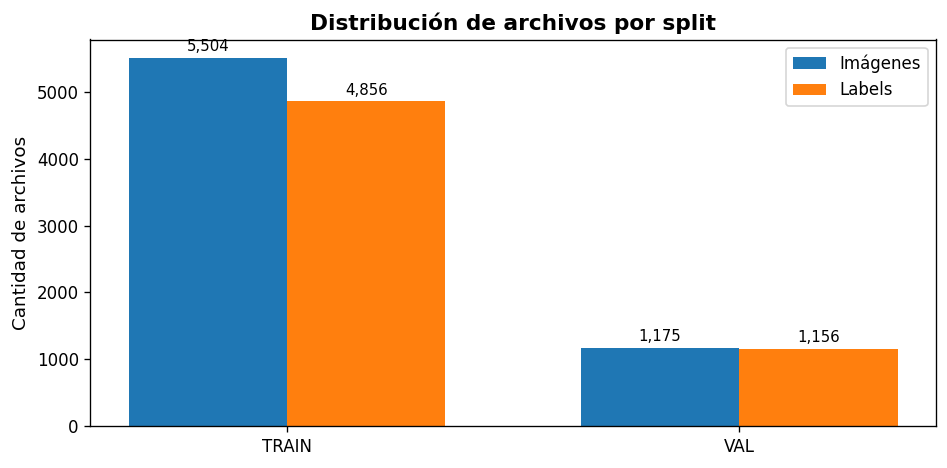


📈 Gráfica guardada en: /content/eda_conteo_splits_baokhang9826_YOLO.png

🔎 REVISIÓN DE CARPETA TEST
⚠️ No existe test en formato YOLO estándar:
   /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/data/test/images
   /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/data/test/labels

ℹ️ En tu resultado, test parece estar organizado como:
   data/test/fall
   data/test/non_fall
   data/test/video

   Por eso no se incluye en el conteo YOLO de entrenamiento.


In [4]:
# ============================================================
# CELDA 4 – Conteo de imágenes y labels por split
#           Dataset: baokhang9826_YOLO
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── 1. Rutas del dataset ────────────────────────────────────

BASE = Path("/content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO")
YOLO = BASE / "data"

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# En este dataset el formato YOLO estándar aparece en train y val
# El test parece estar como videos/carpetas fall y non_fall, no como test/images y test/labels
SPLITS = ["train", "val"]

print("=" * 70)
print("📊 CONTEO DE ARCHIVOS POR SPLIT")
print("=" * 70)

print(f"📁 BASE : {BASE}")
print(f"📁 YOLO : {YOLO}")

# ── 2. Función de conteo ────────────────────────────────────

def contar_archivos(directorio, tipo="cualquiera", recursivo=True):
    """
    Cuenta archivos en un directorio filtrando por tipo.

    tipo:
      - 'imagen' para imágenes
      - 'label' para archivos .txt
      - 'cualquiera' para todos los archivos
    """

    if not directorio.exists():
        return 0, f"Carpeta no encontrada: {directorio}"

    try:
        archivos = directorio.rglob("*") if recursivo else directorio.iterdir()

        count = 0

        for entry in archivos:
            if not entry.is_file():
                continue

            if tipo == "imagen":
                if entry.suffix.lower() in IMG_EXTS:
                    count += 1

            elif tipo == "label":
                if entry.suffix.lower() == ".txt":
                    count += 1

            else:
                count += 1

        return count, None

    except OSError as e:
        return 0, f"Error I/O: {e}"

# ── 3. Conteo por split ─────────────────────────────────────

resumen_conteo = {}

for split in SPLITS:

    # Estructura real de tu dataset:
    # data/train/images
    # data/train/labels
    # data/val/images
    # data/val/labels

    img_dir = YOLO / split / "images"
    lbl_dir = YOLO / split / "labels"

    n_img, e_img = contar_archivos(img_dir, "imagen")
    n_lbl, e_lbl = contar_archivos(lbl_dir, "label")

    resumen_conteo[split] = {
        "imagenes": n_img,
        "labels": n_lbl,
        "ruta_imagenes": str(img_dir),
        "ruta_labels": str(lbl_dir),
        "error_imagenes": e_img,
        "error_labels": e_lbl,
    }

    estado_img = "✅" if not e_img else "❌"
    estado_lbl = "✅" if not e_lbl else "❌"

    print(
        f"  {split.upper():<6} │ "
        f"{estado_img} Imágenes: {n_img:>6,} │ "
        f"{estado_lbl} Labels: {n_lbl:>6,}"
    )

    if e_img:
        print(f"          ⚠️ {e_img}")

    if e_lbl:
        print(f"          ⚠️ {e_lbl}")

print("=" * 70)

total_img = sum(v["imagenes"] for v in resumen_conteo.values())
total_lbl = sum(v["labels"] for v in resumen_conteo.values())

print(
    f"  {'TOTAL':<6} │ "
    f"   Imágenes: {total_img:>6,} │ "
    f"   Labels: {total_lbl:>6,}"
)

print("=" * 70)

# ── 4. Tabla resumen ────────────────────────────────────────

df_conteo = pd.DataFrame([
    {
        "split": split,
        "imagenes": datos["imagenes"],
        "labels": datos["labels"],
        "diferencia_img_label": datos["imagenes"] - datos["labels"],
        "ruta_imagenes": datos["ruta_imagenes"],
        "ruta_labels": datos["ruta_labels"],
    }
    for split, datos in resumen_conteo.items()
])

print("\n📌 Tabla resumen:")
display(df_conteo)

# ── 5. Gráfica de barras ────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(SPLITS))
w = 0.35

valores_img = [resumen_conteo[s]["imagenes"] for s in SPLITS]
valores_lbl = [resumen_conteo[s]["labels"] for s in SPLITS]

b1 = ax.bar(x - w/2, valores_img, w, label="Imágenes")
b2 = ax.bar(x + w/2, valores_lbl, w, label="Labels")

ax.set_title("Distribución de archivos por split", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([s.upper() for s in SPLITS])
ax.set_ylabel("Cantidad de archivos")
ax.legend()

for bar in list(b1) + list(b2):
    altura = bar.get_height()
    ax.annotate(
        f"{int(altura):,}",
        xy=(bar.get_x() + bar.get_width() / 2, altura),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

OUT_PLOT = "/content/eda_conteo_splits_baokhang9826_YOLO.png"
plt.savefig(OUT_PLOT, dpi=120, bbox_inches="tight")
plt.show()

print(f"\n📈 Gráfica guardada en: {OUT_PLOT}")

# ── 6. Verificación adicional del test ──────────────────────

print("\n" + "=" * 70)
print("🔎 REVISIÓN DE CARPETA TEST")
print("=" * 70)

test_standard_img = YOLO / "test" / "images"
test_standard_lbl = YOLO / "test" / "labels"

if test_standard_img.exists() and test_standard_lbl.exists():
    print("✅ Existe test en formato YOLO estándar.")
    print(f"   Imágenes: {test_standard_img}")
    print(f"   Labels  : {test_standard_lbl}")
else:
    print("⚠️ No existe test en formato YOLO estándar:")
    print(f"   {test_standard_img}")
    print(f"   {test_standard_lbl}")
    print("\nℹ️ En tu resultado, test parece estar organizado como:")
    print("   data/test/fall")
    print("   data/test/non_fall")
    print("   data/test/video")
    print("\n   Por eso no se incluye en el conteo YOLO de entrenamiento.")

In [5]:
# ============================================================
# CELDA – Crear dataset YOLO con distribución 70 / 15 / 15
#        Dataset origen: baokhang9826_YOLO
# ============================================================

from pathlib import Path
from collections import defaultdict, Counter
import random
import shutil
import yaml
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm

# ── 1. Rutas ────────────────────────────────────────────────

BASE = Path("/content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO")

# Dataset original descomprimido
ORIGEN = BASE / "data"

# Nueva carpeta con la distribución deseada
DESTINO = BASE / "YOLO_70_15_15"

YAML_ORIGEN = ORIGEN / "data.yaml"
YAML_DESTINO = DESTINO / "data.yaml"

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# Proporciones deseadas
P_TRAIN = 0.70
P_VAL   = 0.15
P_TEST  = 0.15

SEED = 42
random.seed(SEED)

print("=" * 70)
print("📦 CREANDO DATASET YOLO 70 / 15 / 15")
print("=" * 70)

print(f"📁 Dataset origen : {ORIGEN}")
print(f"📁 Dataset destino: {DESTINO}")

if not ORIGEN.exists():
    raise FileNotFoundError(f"No existe la carpeta origen:\n{ORIGEN}")

# ── 2. Leer clases desde data.yaml ──────────────────────────

def normalizar_names(names):
    """
    Convierte names de data.yaml a lista.
    Soporta:
      names: ['fall', 'non_fall']
      names: {0: 'fall', 1: 'non_fall'}
    """
    if names is None:
        return None

    if isinstance(names, list):
        return names

    if isinstance(names, dict):
        try:
            return [names[k] for k in sorted(names, key=lambda x: int(x))]
        except Exception:
            return list(names.values())

    return None

CLASES_DEFAULT = ["fall", "non_fall"]

if YAML_ORIGEN.exists():
    with open(YAML_ORIGEN, "r", encoding="utf-8") as f:
        ydata = yaml.safe_load(f)

    CLASS_NAMES = normalizar_names(ydata.get("names"))

    if CLASS_NAMES is None:
        CLASS_NAMES = CLASES_DEFAULT
        print("⚠️ No se pudieron leer clases desde data.yaml. Usando clases por defecto.")
else:
    CLASS_NAMES = CLASES_DEFAULT
    print("⚠️ No existe data.yaml en origen. Usando clases por defecto.")

NUM_CLASSES = len(CLASS_NAMES)

print(f"✅ Clases: {CLASS_NAMES}")
print(f"✅ Número de clases: {NUM_CLASSES}")

# ── 3. Crear estructura destino ─────────────────────────────

# Si quieres reconstruir desde cero, deja esto en True.
# Si ya lo ejecutaste y no quieres borrar el resultado, cambia a False.
RECREAR_DESTINO = True

if DESTINO.exists() and RECREAR_DESTINO:
    print(f"\n🧹 Eliminando carpeta destino anterior:\n{DESTINO}")
    shutil.rmtree(DESTINO)

for split in ["train", "val", "test"]:
    (DESTINO / "images" / split).mkdir(parents=True, exist_ok=True)
    (DESTINO / "labels" / split).mkdir(parents=True, exist_ok=True)

print("\n✅ Estructura destino creada.")

# ── 4. Recolectar pares imagen-label desde train y val actuales ──

SPLITS_ORIGEN = ["train", "val"]

pares = []

for split in SPLITS_ORIGEN:
    img_dir = ORIGEN / split / "images"
    lbl_dir = ORIGEN / split / "labels"

    if not img_dir.exists():
        print(f"⚠️ No existe carpeta de imágenes: {img_dir}")
        continue

    if not lbl_dir.exists():
        print(f"⚠️ No existe carpeta de labels: {lbl_dir}")
        continue

    imagenes = sorted([
        p for p in img_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in IMG_EXTS
    ])

    for img_path in imagenes:
        rel_img = img_path.relative_to(img_dir)
        label_path = lbl_dir / rel_img.with_suffix(".txt")

        pares.append({
            "split_origen": split,
            "img_path": img_path,
            "label_path": label_path,
            "rel_img": rel_img,
        })

print("\n" + "=" * 70)
print("📊 ARCHIVOS ENCONTRADOS PARA REPARTIR")
print("=" * 70)
print(f"🖼️ Total de imágenes candidatas: {len(pares):,}")

if len(pares) == 0:
    raise RuntimeError("No se encontraron imágenes para repartir.")

# ── 5. Obtener clase principal de cada imagen para dividir estratificado ──

def obtener_clase_principal(label_path):
    """
    Lee un label YOLO y devuelve la clase principal.
    Si hay varias cajas, usa la clase más frecuente en ese archivo.
    Si no existe label o está vacío, devuelve 'empty'.
    """

    if not label_path.exists():
        return "empty"

    clases = []

    try:
        with open(label_path, "r", encoding="utf-8", errors="ignore") as f:
            for line in f:
                line = line.strip()

                if not line:
                    continue

                parts = line.split()

                if len(parts) < 5:
                    continue

                try:
                    cls = int(float(parts[0]))
                    clases.append(cls)
                except Exception:
                    continue

    except Exception:
        return "empty"

    if len(clases) == 0:
        return "empty"

    return Counter(clases).most_common(1)[0][0]

for item in pares:
    item["clase_split"] = obtener_clase_principal(item["label_path"])

conteo_clase_origen = Counter([item["clase_split"] for item in pares])

print("\n📌 Distribución antes de repartir:")
for cls, n in sorted(conteo_clase_origen.items(), key=lambda x: str(x[0])):
    if cls == "empty":
        nombre = "empty/sin_label"
    elif isinstance(cls, int) and 0 <= cls < NUM_CLASSES:
        nombre = CLASS_NAMES[cls]
    else:
        nombre = "clase_desconocida"

    print(f"  {cls} ({nombre}): {n:,} imágenes")

# ── 6. Split estratificado 70 / 15 / 15 ─────────────────────

grupos = defaultdict(list)

for item in pares:
    grupos[item["clase_split"]].append(item)

asignaciones = {
    "train": [],
    "val": [],
    "test": []
}

for clase, items in grupos.items():
    random.shuffle(items)

    n = len(items)

    n_train = int(round(n * P_TRAIN))
    n_val   = int(round(n * P_VAL))

    # El resto queda para test
    n_test = n - n_train - n_val

    # Ajuste por seguridad si alguna clase tiene muy pocos ejemplos
    if n >= 3:
        if n_train == 0:
            n_train = 1
        if n_val == 0:
            n_val = 1
        n_test = n - n_train - n_val

        if n_test < 0:
            n_test = 0

    train_items = items[:n_train]
    val_items   = items[n_train:n_train + n_val]
    test_items  = items[n_train + n_val:]

    asignaciones["train"].extend(train_items)
    asignaciones["val"].extend(val_items)
    asignaciones["test"].extend(test_items)

print("\n" + "=" * 70)
print("📊 DISTRIBUCIÓN NUEVA")
print("=" * 70)

total_nuevo = sum(len(v) for v in asignaciones.values())

for split in ["train", "val", "test"]:
    n = len(asignaciones[split])
    pct = 100 * n / total_nuevo if total_nuevo > 0 else 0
    print(f"{split.upper():<6}: {n:>7,} imágenes | {pct:6.2f}%")

# ── 7. Copiar imágenes y labels al nuevo formato ────────────

def nombre_seguro(item):
    """
    Crea un nombre único para evitar choques entre train/val originales.
    Ejemplo:
      train__fall001.jpg
      val__fall001.jpg
    """

    split_origen = item["split_origen"]
    rel = item["rel_img"]

    partes = [split_origen] + list(rel.parts)
    nombre = "__".join(partes)

    return nombre

print("\n" + "=" * 70)
print("📂 COPIANDO ARCHIVOS AL NUEVO DATASET")
print("=" * 70)

copiados = {
    "train": 0,
    "val": 0,
    "test": 0,
}

labels_faltantes = 0

for split_destino, items in asignaciones.items():

    for item in tqdm(items, desc=f"Copiando {split_destino}", leave=False):

        img_src = item["img_path"]
        lbl_src = item["label_path"]

        img_name = nombre_seguro(item)
        lbl_name = Path(img_name).with_suffix(".txt").name

        img_dst = DESTINO / "images" / split_destino / img_name
        lbl_dst = DESTINO / "labels" / split_destino / lbl_name

        shutil.copy2(img_src, img_dst)

        if lbl_src.exists():
            shutil.copy2(lbl_src, lbl_dst)
        else:
            # YOLO acepta labels vacíos para imágenes sin objeto
            lbl_dst.touch()
            labels_faltantes += 1

        copiados[split_destino] += 1

print("\n✅ Copia finalizada.")
print(f"⚠️ Labels faltantes creados como .txt vacío: {labels_faltantes:,}")

# ── 8. Crear data.yaml nuevo ────────────────────────────────

data_yaml_content = {
    "path": str(DESTINO),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": NUM_CLASSES,
    "names": CLASS_NAMES,
}

with open(YAML_DESTINO, "w", encoding="utf-8") as f:
    yaml.dump(
        data_yaml_content,
        f,
        default_flow_style=False,
        allow_unicode=True,
        sort_keys=False
    )

print("\n✅ data.yaml creado:")
print(YAML_DESTINO)

# ── 9. Verificación final ───────────────────────────────────

print("\n" + "=" * 70)
print("🔍 VERIFICACIÓN FINAL")
print("=" * 70)

resumen = []

for split in ["train", "val", "test"]:
    img_dir = DESTINO / "images" / split
    lbl_dir = DESTINO / "labels" / split

    imgs = [
        p for p in img_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in IMG_EXTS
    ]

    lbls = [
        p for p in lbl_dir.rglob("*.txt")
        if p.is_file()
    ]

    resumen.append({
        "split": split,
        "imagenes": len(imgs),
        "labels": len(lbls),
        "porcentaje_imagenes": round(100 * len(imgs) / total_nuevo, 2) if total_nuevo > 0 else 0,
    })

    print(f"{split.upper():<6} │ Imágenes: {len(imgs):>7,} │ Labels: {len(lbls):>7,}")

df_resumen = pd.DataFrame(resumen)

print("\n📋 Resumen final:")
display(df_resumen)

# ── 10. Revisar distribución de clases final ─────────────────

print("\n" + "=" * 70)
print("📊 DISTRIBUCIÓN DE CLASES FINAL")
print("=" * 70)

def leer_clases_split_final(split):
    lbl_dir = DESTINO / "labels" / split
    ids = []

    for f in lbl_dir.rglob("*.txt"):
        with open(f, "r", encoding="utf-8", errors="ignore") as fh:
            for line in fh:
                line = line.strip()

                if not line:
                    continue

                parts = line.split()

                if len(parts) >= 5:
                    try:
                        ids.append(int(float(parts[0])))
                    except Exception:
                        pass

    return Counter(ids)

dist_final = {}

for split in ["train", "val", "test"]:
    dist_final[split] = leer_clases_split_final(split)

df_dist_final = pd.DataFrame(
    {
        split: [
            dist_final[split].get(i, 0)
            for i in range(NUM_CLASSES)
        ]
        for split in ["train", "val", "test"]
    },
    index=CLASS_NAMES
)

df_dist_final["TOTAL"] = df_dist_final.sum(axis=1)

display(df_dist_final)

print("\n" + "=" * 70)
print("✅ DATASET FINAL LISTO")
print("=" * 70)
print(f"📁 Carpeta final : {DESTINO}")
print(f"📄 data.yaml     : {YAML_DESTINO}")

📦 CREANDO DATASET YOLO 70 / 15 / 15
📁 Dataset origen : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/data
📁 Dataset destino: /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15
✅ Clases: ['fall', 'non_fall']
✅ Número de clases: 2

✅ Estructura destino creada.

📊 ARCHIVOS ENCONTRADOS PARA REPARTIR
🖼️ Total de imágenes candidatas: 6,679

📌 Distribución antes de repartir:
  0 (fall): 2,188 imágenes
  1 (non_fall): 3,824 imágenes
  empty (empty/sin_label): 667 imágenes

📊 DISTRIBUCIÓN NUEVA
TRAIN :   4,676 imágenes |  70.01%
VAL   :   1,002 imágenes |  15.00%
TEST  :   1,001 imágenes |  14.99%

📂 COPIANDO ARCHIVOS AL NUEVO DATASET


Copiando train:   0%|          | 0/4676 [00:00<?, ?it/s]

Copiando val:   0%|          | 0/1002 [00:00<?, ?it/s]

Copiando test:   0%|          | 0/1001 [00:00<?, ?it/s]


✅ Copia finalizada.
⚠️ Labels faltantes creados como .txt vacío: 667

✅ data.yaml creado:
/content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15/data.yaml

🔍 VERIFICACIÓN FINAL
TRAIN  │ Imágenes:   4,676 │ Labels:   4,676
VAL    │ Imágenes:   1,002 │ Labels:   1,002
TEST   │ Imágenes:   1,001 │ Labels:   1,001

📋 Resumen final:


,split,imagenes,labels,porcentaje_imagenes
0,train,4676,4676,70.01
1,val,1002,1002,15.00
2,test,1001,1001,14.99



📊 DISTRIBUCIÓN DE CLASES FINAL


,train,val,test,TOTAL
fall,1555,331,334,2220
non_fall,2702,586,582,3870



✅ DATASET FINAL LISTO
📁 Carpeta final : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15
📄 data.yaml     : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15/data.yaml


📊 CONTEO DE ARCHIVOS POR SPLIT
📁 Dataset YOLO : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15
📄 data.yaml    : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15/data.yaml
  TRAIN  │ ✅ Imágenes:   4,676 │ ✅ Labels:   4,676
  VAL    │ ✅ Imágenes:   1,002 │ ✅ Labels:   1,002
  TEST   │ ✅ Imágenes:   1,001 │ ✅ Labels:   1,001
  TOTAL  │    Imágenes:   6,679 │    Labels:   6,679

📋 Tabla resumen:


,split,imagenes,labels,porcentaje_imagenes,diferencia_img_label
0,train,4676,4676,70.01,0
1,val,1002,1002,15.00,0
2,test,1001,1001,14.99,0



🎯 VALIDACIÓN DE DISTRIBUCIÓN ESPERADA 70 / 15 / 15
  TRAIN  │ Real:  70.01% │ Esperado:  70.0% │ Diferencia:   0.01%
  VAL    │ Real:  15.00% │ Esperado:  15.0% │ Diferencia:   0.00%
  TEST   │ Real:  14.99% │ Esperado:  15.0% │ Diferencia:  -0.01%


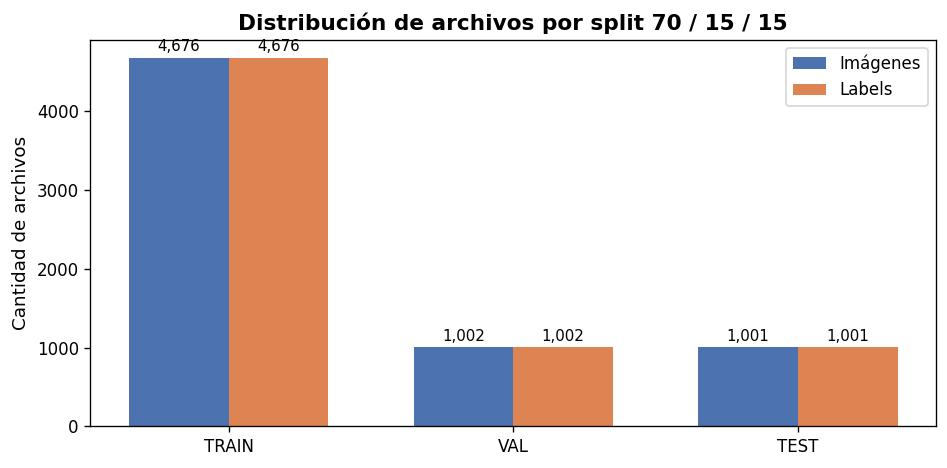


📈 Gráfica guardada en: /content/eda_conteo_splits_70_15_15.png

✅ RUTA PARA ENTRENAMIENTO
DATA_YAML = /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15/data.yaml


In [6]:
# ============================================================
# CELDA 3 – Conteo de imágenes y labels por split
#           Dataset redistribuido 70 / 15 / 15
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Rutas del dataset redistribuido ─────────────────────────

YOLO = Path("/content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15")
DATA_YAML = YOLO / "data.yaml"

SPLITS = ["train", "val", "test"]

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

# ── Función para contar archivos ────────────────────────────

def contar_archivos(directorio, tipo="cualquiera"):
    """Cuenta archivos en un directorio filtrando por tipo."""

    if not directorio.exists():
        return 0, f"Carpeta no encontrada: {directorio}"

    try:
        count = 0

        for entry in directorio.iterdir():
            if not entry.is_file():
                continue

            if tipo == "imagen":
                if entry.suffix.lower() in IMG_EXTS:
                    count += 1

            elif tipo == "label":
                if entry.suffix.lower() == ".txt":
                    count += 1

            else:
                count += 1

        return count, None

    except OSError as e:
        return 0, f"Error I/O: {e}"

# ── Conteo por split ────────────────────────────────────────

print("=" * 70)
print("📊 CONTEO DE ARCHIVOS POR SPLIT")
print("=" * 70)

print(f"📁 Dataset YOLO : {YOLO}")
print(f"📄 data.yaml    : {DATA_YAML}")
print("=" * 70)

resumen_conteo = {}

for split in SPLITS:

    img_dir = YOLO / "images" / split
    lbl_dir = YOLO / "labels" / split

    n_img, e_img = contar_archivos(img_dir, "imagen")
    n_lbl, e_lbl = contar_archivos(lbl_dir, "label")

    resumen_conteo[split] = {
        "imagenes": n_img,
        "labels": n_lbl,
        "error_imagenes": e_img,
        "error_labels": e_lbl
    }

    estado_img = "✅" if not e_img else "❌"
    estado_lbl = "✅" if not e_lbl else "❌"

    print(
        f"  {split.upper():<6} │ "
        f"{estado_img} Imágenes: {n_img:>7,} │ "
        f"{estado_lbl} Labels: {n_lbl:>7,}"
    )

    if e_img:
        print(f"          ⚠️ {e_img}")

    if e_lbl:
        print(f"          ⚠️ {e_lbl}")

print("=" * 70)

total_img = sum(v["imagenes"] for v in resumen_conteo.values())
total_lbl = sum(v["labels"] for v in resumen_conteo.values())

print(
    f"  {'TOTAL':<6} │ "
    f"   Imágenes: {total_img:>7,} │ "
    f"   Labels: {total_lbl:>7,}"
)

print("=" * 70)

# ── Tabla resumen con porcentajes ───────────────────────────

df_conteo = pd.DataFrame([
    {
        "split": split,
        "imagenes": resumen_conteo[split]["imagenes"],
        "labels": resumen_conteo[split]["labels"],
        "porcentaje_imagenes": round(
            100 * resumen_conteo[split]["imagenes"] / total_img, 2
        ) if total_img > 0 else 0,
        "diferencia_img_label": resumen_conteo[split]["imagenes"] - resumen_conteo[split]["labels"]
    }
    for split in SPLITS
])

print("\n📋 Tabla resumen:")
display(df_conteo)

# ── Validación rápida de proporciones esperadas ─────────────

print("\n" + "=" * 70)
print("🎯 VALIDACIÓN DE DISTRIBUCIÓN ESPERADA 70 / 15 / 15")
print("=" * 70)

proporciones_esperadas = {
    "train": 70,
    "val": 15,
    "test": 15
}

for split in SPLITS:
    pct_real = df_conteo.loc[df_conteo["split"] == split, "porcentaje_imagenes"].values[0]
    pct_esp = proporciones_esperadas[split]
    diferencia = pct_real - pct_esp

    print(
        f"  {split.upper():<6} │ "
        f"Real: {pct_real:>6.2f}% │ "
        f"Esperado: {pct_esp:>5.1f}% │ "
        f"Diferencia: {diferencia:>6.2f}%"
    )

# ── Gráfica de barras ───────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(SPLITS))
w = 0.35

valores_img = [resumen_conteo[s]["imagenes"] for s in SPLITS]
valores_lbl = [resumen_conteo[s]["labels"] for s in SPLITS]

b1 = ax.bar(
    x - w / 2,
    valores_img,
    w,
    label="Imágenes",
    color="#4C72B0"
)

b2 = ax.bar(
    x + w / 2,
    valores_lbl,
    w,
    label="Labels",
    color="#DD8452"
)

ax.set_title("Distribución de archivos por split 70 / 15 / 15", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([s.upper() for s in SPLITS])
ax.set_ylabel("Cantidad de archivos")
ax.legend()

for bar in list(b1) + list(b2):
    altura = bar.get_height()

    ax.annotate(
        f"{int(altura):,}",
        xy=(bar.get_x() + bar.get_width() / 2, altura),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

plt.tight_layout()

OUT_PLOT = "/content/eda_conteo_splits_70_15_15.png"

plt.savefig(
    OUT_PLOT,
    dpi=120,
    bbox_inches="tight"
)

plt.show()

print(f"\n📈 Gráfica guardada en: {OUT_PLOT}")

# ── Ruta que usarás para entrenar YOLO ──────────────────────

print("\n" + "=" * 70)
print("✅ RUTA PARA ENTRENAMIENTO")
print("=" * 70)
print(f"DATA_YAML = {DATA_YAML}")

📊 Sección 4 – Distribución de Clases por Split

📊 DISTRIBUCIÓN DE CLASES POR SPLIT
📁 Dataset YOLO : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15
📄 data.yaml    : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15/data.yaml
✅ Clases leídas desde data.yaml: ['fall', 'non_fall']
📌 Número de clases: 2

📊 Leyendo labels de todos los splits...


Leyendo labels train:   0%|          | 0/4676 [00:00<?, ?it/s]


  TRAIN : 4,257 anotaciones
          Labels vacíos       : 467
          Líneas mal formadas : 0
          IDs fuera de rango  : 0


Leyendo labels val:   0%|          | 0/1002 [00:00<?, ?it/s]


  VAL   : 917 anotaciones
          Labels vacíos       : 100
          Líneas mal formadas : 0
          IDs fuera de rango  : 0


Leyendo labels test:   0%|          | 0/1001 [00:00<?, ?it/s]


  TEST  : 916 anotaciones
          Labels vacíos       : 100
          Líneas mal formadas : 0
          IDs fuera de rango  : 0

📋 TABLA DE DISTRIBUCIÓN DE CLASES


,train,val,test,TOTAL
fall,1555,331,334,2220
non_fall,2702,586,582,3870



📋 PORCENTAJE DE CLASES POR SPLIT


,train,val,test
fall,36.53,36.1,36.46
non_fall,63.47,63.9,63.54


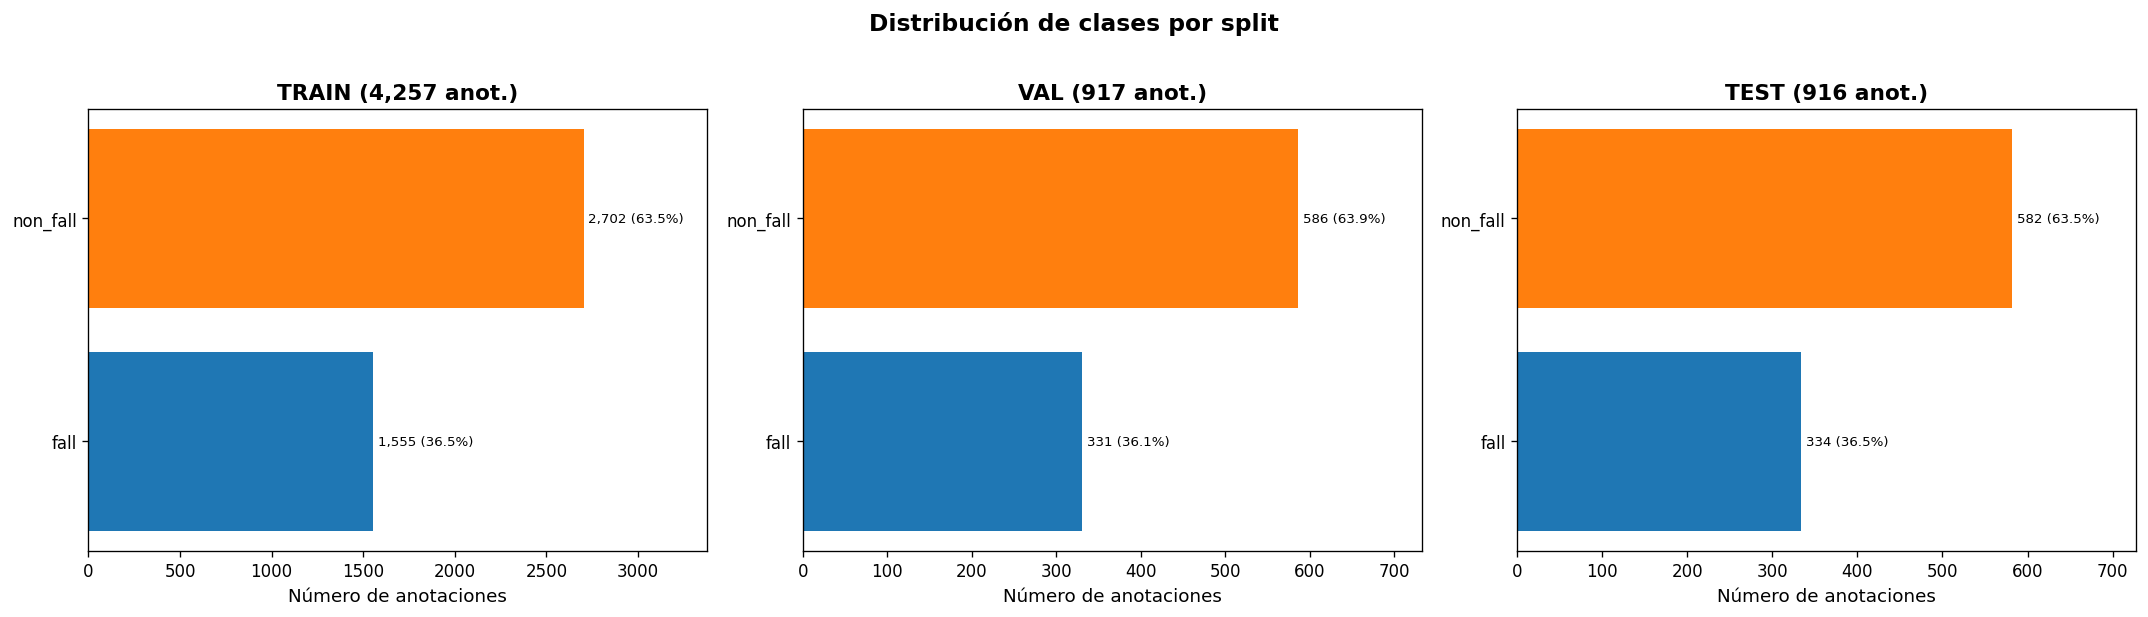


📈 Gráfica guardada en: /content/eda_distribucion_clases_70_15_15.png

⚠️ ANÁLISIS DE DESBALANCEO EN TRAIN
    fall           :   1,555 anotaciones |  36.53%
    non_fall       :   2,702 anotaciones |  63.47%

📌 Relación clase mayor / clase menor: 1.74x
⚠️ Hay desbalanceo moderado.

✅ DATASET ANALIZADO
📁 YOLO      : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15
📄 DATA_YAML : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15/data.yaml


In [7]:
# ============================================================
# CELDA 4 – Distribución de clases en train / val / test
#           Dataset redistribuido 70 / 15 / 15
# ============================================================

from pathlib import Path
from collections import Counter
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm

# ── 1. Rutas del dataset redistribuido ──────────────────────

YOLO = Path("/content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15")
DATA_YAML = YOLO / "data.yaml"

SPLITS = ["train", "val", "test"]

print("=" * 70)
print("📊 DISTRIBUCIÓN DE CLASES POR SPLIT")
print("=" * 70)

print(f"📁 Dataset YOLO : {YOLO}")
print(f"📄 data.yaml    : {DATA_YAML}")

# ── 2. Leer nombres de clases desde data.yaml ───────────────

def normalizar_names(names):
    """
    Convierte names de data.yaml a lista.
    Soporta:
      names: ['fall', 'non_fall']
      names: {0: 'fall', 1: 'non_fall'}
    """

    if names is None:
        return None

    if isinstance(names, list):
        return names

    if isinstance(names, dict):
        try:
            return [names[k] for k in sorted(names, key=lambda x: int(x))]
        except Exception:
            return list(names.values())

    return None


CLASES_DEFAULT = ["fall", "non_fall"]

if DATA_YAML.exists():
    with open(DATA_YAML, "r", encoding="utf-8") as f:
        ydata = yaml.safe_load(f)

    CLASS_NAMES = normalizar_names(ydata.get("names"))

    if CLASS_NAMES is None:
        CLASS_NAMES = CLASES_DEFAULT
        print("⚠️ data.yaml existe, pero no trae clases válidas.")
        print(f"   Usando clases por defecto: {CLASS_NAMES}")
    else:
        print(f"✅ Clases leídas desde data.yaml: {CLASS_NAMES}")

else:
    CLASS_NAMES = CLASES_DEFAULT
    print("⚠️ No se encontró data.yaml.")
    print(f"   Usando clases por defecto: {CLASS_NAMES}")

NUM_CLASSES = len(CLASS_NAMES)

print(f"📌 Número de clases: {NUM_CLASSES}")

# ── 3. Leer labels por split ────────────────────────────────

def leer_labels_split(split):
    """
    Lee todos los .txt del split y devuelve lista de class_ids.

    Estructura esperada después de la redistribución:
      labels/train
      labels/val
      labels/test
    """

    lbl_dir = YOLO / "labels" / split

    class_ids = []
    labels_vacios = 0
    lineas_mal_formadas = 0
    ids_fuera_rango = 0

    if not lbl_dir.exists():
        print(f"  ❌ No existe: {lbl_dir}")
        return class_ids, labels_vacios, lineas_mal_formadas, ids_fuera_rango

    label_files = sorted([
        f for f in lbl_dir.iterdir()
        if f.is_file() and f.suffix.lower() == ".txt"
    ])

    for f in tqdm(label_files, desc=f"Leyendo labels {split}", leave=False):
        try:
            with open(f, "r", encoding="utf-8", errors="ignore") as fh:
                lines = [line.strip() for line in fh.readlines() if line.strip()]

            if len(lines) == 0:
                labels_vacios += 1
                continue

            for line in lines:
                parts = line.split()

                if len(parts) < 5:
                    lineas_mal_formadas += 1
                    continue

                try:
                    class_id = int(float(parts[0]))

                    if class_id < 0 or class_id >= NUM_CLASSES:
                        ids_fuera_rango += 1

                    class_ids.append(class_id)

                except Exception:
                    lineas_mal_formadas += 1

        except Exception:
            lineas_mal_formadas += 1

    return class_ids, labels_vacios, lineas_mal_formadas, ids_fuera_rango

# ── 4. Construir distribución de clases ─────────────────────

print("\n📊 Leyendo labels de todos los splits...")

dist_clases = {}
diagnostico = {}

for split in SPLITS:
    ids, labels_vacios, lineas_mal_formadas, ids_fuera_rango = leer_labels_split(split)

    dist_clases[split] = Counter(ids)

    diagnostico[split] = {
        "labels_vacios": labels_vacios,
        "lineas_mal_formadas": lineas_mal_formadas,
        "ids_fuera_rango": ids_fuera_rango
    }

    total = sum(dist_clases[split].values())

    print(f"\n  {split.upper():<6}: {total:,} anotaciones")
    print(f"          Labels vacíos       : {labels_vacios:,}")
    print(f"          Líneas mal formadas : {lineas_mal_formadas:,}")
    print(f"          IDs fuera de rango  : {ids_fuera_rango:,}")

# ── 5. DataFrame resumen ────────────────────────────────────

df_dist = pd.DataFrame(
    {
        split: [
            dist_clases[split].get(i, 0)
            for i in range(NUM_CLASSES)
        ]
        for split in SPLITS
    },
    index=CLASS_NAMES
)

df_dist["TOTAL"] = df_dist.sum(axis=1)

print("\n" + "=" * 70)
print("📋 TABLA DE DISTRIBUCIÓN DE CLASES")
print("=" * 70)

display(df_dist)

# ── 6. Porcentaje por split ─────────────────────────────────

df_pct = df_dist[SPLITS].copy()

for split in SPLITS:
    total_split = df_pct[split].sum()

    if total_split > 0:
        df_pct[split] = 100 * df_pct[split] / total_split
    else:
        df_pct[split] = 0

print("\n" + "=" * 70)
print("📋 PORCENTAJE DE CLASES POR SPLIT")
print("=" * 70)

display(df_pct.round(2))

# ── 7. Gráficas ─────────────────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

paleta = sns.color_palette("tab10", NUM_CLASSES)

for ax, split in zip(axes, SPLITS):

    vals = [
        dist_clases[split].get(i, 0)
        for i in range(NUM_CLASSES)
    ]

    total = sum(vals)

    bars = ax.barh(
        CLASS_NAMES,
        vals,
        color=paleta
    )

    ax.set_title(
        f"{split.upper()} ({total:,} anot.)",
        fontweight="bold"
    )

    ax.set_xlabel("Número de anotaciones")

    max_val = max(vals) if vals else 0

    for bar, v in zip(bars, vals):

        pct = f"{100 * v / total:.1f}%" if total > 0 else "0%"

        ax.text(
            bar.get_width() + max_val * 0.01 if max_val > 0 else 0.1,
            bar.get_y() + bar.get_height() / 2,
            f"{v:,} ({pct})",
            va="center",
            fontsize=8
        )

    ax.set_xlim(0, max_val * 1.25 if max_val > 0 else 1)

plt.suptitle(
    "Distribución de clases por split",
    fontsize=14,
    fontweight="bold",
    y=1.02
)

plt.tight_layout()

OUT_PLOT = "/content/eda_distribucion_clases_70_15_15.png"

plt.savefig(
    OUT_PLOT,
    dpi=120,
    bbox_inches="tight"
)

plt.show()

print(f"\n📈 Gráfica guardada en: {OUT_PLOT}")

# ── 8. Detección de desbalanceo en TRAIN ────────────────────

print("\n" + "=" * 70)
print("⚠️ ANÁLISIS DE DESBALANCEO EN TRAIN")
print("=" * 70)

vals_train = np.array([
    dist_clases["train"].get(i, 0)
    for i in range(NUM_CLASSES)
])

if vals_train.sum() > 0:

    pcts = 100 * vals_train / vals_train.sum()

    for cls, n, p in zip(CLASS_NAMES, vals_train, pcts):

        # Para clasificación binaria, usar >40% marcaría casi todo como desbalanceado.
        # Por eso se usa un criterio más razonable para fall / non_fall.
        if NUM_CLASSES == 2:
            alerta = " ← posible desbalanceo" if p < 30 or p > 70 else ""
        else:
            alerta = " ← posible desbalanceo" if p < 5 or p > 40 else ""

        print(f"    {cls:<15}: {n:>7,} anotaciones | {p:6.2f}%{alerta}")

    clase_mayor = vals_train.max()
    clase_menor = vals_train.min()

    ratio = clase_mayor / max(clase_menor, 1)

    print(f"\n📌 Relación clase mayor / clase menor: {ratio:.2f}x")

    if ratio <= 1.5:
        print("✅ Distribución bastante equilibrada.")
    elif ratio <= 3:
        print("⚠️ Hay desbalanceo moderado.")
    else:
        print("🚨 Hay desbalanceo fuerte. Conviene revisar antes de entrenar.")

else:
    print("⚠️ No se encontraron anotaciones en train.")

# ── 9. Ruta final usada ─────────────────────────────────────

print("\n" + "=" * 70)
print("✅ DATASET ANALIZADO")
print("=" * 70)

print(f"📁 YOLO      : {YOLO}")
print(f"📄 DATA_YAML : {DATA_YAML}")

# ⚖️ Sección 4b – Equilibrado del Dataset mediante Aumentación (Albumentations)
> Se generan nuevas imágenes **solo para las clases minoritarias** del split `train` hasta acercarse al umbral objetivo.
> Las imágenes y labels aumentados se guardan **en las mismas carpetas** `images/train` y `labels/train`.

In [9]:
# ============================================================
# CELDA 4b-DIAGNÓSTICO – Prueba paso a paso para verificar
#                         por qué generadas = 0
#                         Dataset: baokhang9826_YOLO
#                         Estructura: YOLO_70_15_15
# ============================================================

from pathlib import Path
import cv2
import traceback
import albumentations as A
import numpy as np
import yaml

# ============================================================
# 1. RUTAS DEL DATASET REDISTRIBUIDO
# ============================================================

YOLO = Path("/content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15")
DATA_YAML = YOLO / "data.yaml"

img_dir_train = YOLO / "images" / "train"
lbl_dir_train = YOLO / "labels" / "train"

IMG_EXTS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp",
    ".JPG", ".JPEG", ".PNG", ".BMP", ".WEBP"
}

print("=" * 70)
print("🔍 DIAGNÓSTICO PASO A PASO DE AUGMENTATION")
print("=" * 70)

print(f"📁 YOLO      : {YOLO}")
print(f"📁 Imágenes  : {img_dir_train}")
print(f"📁 Labels    : {lbl_dir_train}")
print(f"📄 data.yaml : {DATA_YAML}")

# ============================================================
# 2. LEER CLASES DESDE data.yaml
# ============================================================

def normalizar_names(names):
    """
    Convierte names del data.yaml a lista.
    Soporta:
      names: ['fall', 'non_fall']
      names: {0: 'fall', 1: 'non_fall'}
    """

    if names is None:
        return None

    if isinstance(names, list):
        return names

    if isinstance(names, dict):
        try:
            return [names[k] for k in sorted(names, key=lambda x: int(x))]
        except Exception:
            return list(names.values())

    return None


CLASES_DEFAULT = ["fall", "non_fall"]

if DATA_YAML.exists():
    with open(DATA_YAML, "r", encoding="utf-8") as f:
        ydata = yaml.safe_load(f)

    CLASS_NAMES = normalizar_names(ydata.get("names"))

    if CLASS_NAMES is None:
        CLASS_NAMES = CLASES_DEFAULT
        print("\n⚠️ data.yaml existe, pero no trae clases válidas.")
        print(f"   Usando clases por defecto: {CLASS_NAMES}")

else:
    CLASS_NAMES = CLASES_DEFAULT
    print("\n⚠️ No se encontró data.yaml.")
    print(f"   Usando clases por defecto: {CLASS_NAMES}")

NUM_CLASSES = len(CLASS_NAMES)

print(f"\n✅ Clases detectadas : {CLASS_NAMES}")
print(f"✅ Número de clases  : {NUM_CLASSES}")

# ============================================================
# 3. CLASE OBJETIVO PARA EL DIAGNÓSTICO
# ============================================================

# Cambia aquí si quieres probar otra clase:
# Opciones esperadas: "fall" o "non_fall"

CLASE_OBJETIVO = "fall"

class_names_lower = [c.lower() for c in CLASS_NAMES]

if CLASE_OBJETIVO.lower() not in class_names_lower:
    raise ValueError(
        f"La clase objetivo '{CLASE_OBJETIVO}' no existe en CLASS_NAMES.\n"
        f"Clases disponibles: {CLASS_NAMES}\n\n"
        "Cambia CLASE_OBJETIVO por una de las clases disponibles."
    )

cls_id_test = class_names_lower.index(CLASE_OBJETIVO.lower())

print(f"\n🎯 Clase objetivo : {CLASE_OBJETIVO}")
print(f"🎯 class_id       : {cls_id_test}")

# ============================================================
# 4. HELPERS
# ============================================================

def leer_txt_seguro(path):
    """
    Lee archivo YOLO .txt con formato:
      class_id cx cy w h
    """

    bboxes = []

    try:
        with open(path, "r", encoding="utf-8", errors="ignore") as fh:
            for line in fh:
                parts = line.strip().split()

                if len(parts) == 5:
                    try:
                        bboxes.append((
                            int(float(parts[0])),
                            float(parts[1]),
                            float(parts[2]),
                            float(parts[3]),
                            float(parts[4])
                        ))
                    except ValueError:
                        pass

    except OSError:
        pass

    return bboxes


def leer_imagen_bgr(path):
    """
    Lee una imagen con OpenCV.
    Si falla, intenta leer con PIL.
    """

    img = cv2.imread(str(path))

    if img is not None:
        return img

    try:
        from PIL import Image as PILImage

        pil_img = PILImage.open(path).convert("RGB")
        return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

    except Exception:
        return None


def buscar_imagen(stem, img_dir):
    """
    Busca una imagen cuyo nombre base coincida con el stem del label.
    """

    for ext in IMG_EXTS:
        p = img_dir / (stem + ext)

        if p.exists():
            return p

    return None

# ============================================================
# 5. VALIDAR CARPETAS
# ============================================================

if not YOLO.exists():
    raise FileNotFoundError(f"No existe la carpeta YOLO:\n{YOLO}")

if not img_dir_train.exists():
    raise FileNotFoundError(f"No existe la carpeta de imágenes train:\n{img_dir_train}")

if not lbl_dir_train.exists():
    raise FileNotFoundError(f"No existe la carpeta de labels train:\n{lbl_dir_train}")

# ============================================================
# 6. BUSCAR UNA IMAGEN REAL DE LA CLASE OBJETIVO
# ============================================================

stem_test = None
bbs_test = None
img_path_test = None

label_files = sorted([
    p for p in lbl_dir_train.rglob("*.txt")
    if p.is_file()
])

print(f"\n📝 Labels encontrados en train: {len(label_files):,}")

for lbl_f in label_files:

    bbs = leer_txt_seguro(lbl_f)

    if any(bb[0] == cls_id_test for bb in bbs):

        img_p = buscar_imagen(lbl_f.stem, img_dir_train)

        if img_p is not None:
            stem_test = lbl_f.stem
            bbs_test = bbs
            img_path_test = img_p
            break

print("\n" + "=" * 70)
print("🔍 RESULTADO DE BÚSQUEDA DE IMAGEN")
print("=" * 70)

if stem_test is None:

    print(f"❌ No se encontró ninguna imagen de clase '{CLASE_OBJETIVO}' con imagen real.")
    print("\nPosibles causas:")
    print("  1. La clase no aparece en train.")
    print("  2. Los labels están vacíos.")
    print("  3. Los nombres de imagen y label no coinciden.")
    print("  4. La redistribución no copió correctamente imágenes y labels.")
    print("  5. La clase objetivo no corresponde al id real del dataset.")

else:

    print(f"✅ Imagen encontrada : {img_path_test}")
    print(f"✅ Stem             : {stem_test}")
    print(f"✅ BBoxes del label : {bbs_test}")

    # ========================================================
    # 7. LEER IMAGEN
    # ========================================================

    img_bgr = leer_imagen_bgr(img_path_test)

    if img_bgr is None:

        print("\n❌ leer_imagen_bgr → None.")
        print("   La imagen no se pudo leer.")

    else:

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        print(f"\n✅ Imagen leída : shape={img_rgb.shape} dtype={img_rgb.dtype}")

        yolo_bboxes = [
            (bb[1], bb[2], bb[3], bb[4])
            for bb in bbs_test
        ]

        class_labels = [
            bb[0]
            for bb in bbs_test
        ]

        print(f"✅ yolo_bboxes  : {yolo_bboxes}")
        print(f"✅ class_labels : {class_labels}")

        # ====================================================
        # 8. VALIDAR BBOXES
        # ====================================================

        print("\n" + "=" * 70)
        print("🔍 VALIDACIÓN DE BBOXES YOLO")
        print("=" * 70)

        print("Formato esperado:")
        print("  class_id cx cy w h")
        print("Donde cx, cy, w, h deben estar normalizados entre 0 y 1.")

        todas_validas = True

        for i, (cx, cy, bw, bh) in enumerate(yolo_bboxes):

            valida = (
                0 <= cx <= 1 and
                0 <= cy <= 1 and
                0 < bw <= 1 and
                0 < bh <= 1
            )

            estado = "✅" if valida else "❌ FUERA DE RANGO"

            print(
                f"bbox[{i}] → "
                f"cx={cx:.4f} cy={cy:.4f} "
                f"bw={bw:.4f} bh={bh:.4f}  {estado}"
            )

            if not valida:
                todas_validas = False

        if todas_validas:
            print("\n✅ Todas las bboxes están dentro del rango esperado.")
        else:
            print("\n⚠️ Hay bboxes fuera de rango. Se aplicará clamping para probar.")

        # ====================================================
        # 9. CLAMPEAR BBOXES
        # ====================================================

        bboxes_clamped = []

        for cx, cy, bw, bh in yolo_bboxes:

            cx = max(0.001, min(0.999, cx))
            cy = max(0.001, min(0.999, cy))

            bw = max(
                0.001,
                min(
                    min(2 * cx, 2 * (1 - cx), 1.0),
                    bw
                )
            )

            bh = max(
                0.001,
                min(
                    min(2 * cy, 2 * (1 - cy), 1.0),
                    bh
                )
            )

            bboxes_clamped.append((cx, cy, bw, bh))

        print("\n🔧 BBoxes clampeadas:")
        print(bboxes_clamped)

        # ====================================================
        # 10. PRUEBA 1 – HORIZONTAL FLIP SIN FILTRO FUERTE
        # ====================================================

        print("\n" + "=" * 70)
        print("🔍 PRUEBA 1: HorizontalFlip con min_visibility=0.0")
        print("=" * 70)

        try:

            t_sin_vis = A.Compose(
                [
                    A.HorizontalFlip(p=1.0),
                ],
                bbox_params=A.BboxParams(
                    format="yolo",
                    label_fields=["class_labels"],
                    min_visibility=0.0
                )
            )

            res = t_sin_vis(
                image=img_rgb,
                bboxes=bboxes_clamped,
                class_labels=class_labels
            )

            print(f"✅ bboxes resultado : {res['bboxes']}")
            print(f"✅ labels resultado : {res['class_labels']}")

            if len(res["bboxes"]) == 0:
                print("⚠️ Incluso con min_visibility=0.0 no quedaron bboxes.")

        except Exception as e:

            print(f"❌ EXCEPCIÓN EN PRUEBA 1: {e}")
            traceback.print_exc()

        # ====================================================
        # 11. PRUEBA 2 – HORIZONTAL FLIP CON min_visibility=0.3
        # ====================================================

        print("\n" + "=" * 70)
        print("🔍 PRUEBA 2: HorizontalFlip con min_visibility=0.3")
        print("=" * 70)

        try:

            t_con_vis = A.Compose(
                [
                    A.HorizontalFlip(p=1.0),
                ],
                bbox_params=A.BboxParams(
                    format="yolo",
                    label_fields=["class_labels"],
                    min_visibility=0.3
                )
            )

            res2 = t_con_vis(
                image=img_rgb,
                bboxes=bboxes_clamped,
                class_labels=class_labels
            )

            print(f"✅ bboxes resultado : {res2['bboxes']}")
            print(f"✅ labels resultado : {res2['class_labels']}")

            if len(res2["bboxes"]) == 0:
                print("⚠️ bboxes vacío → min_visibility=0.3 está filtrando todo.")

        except Exception as e:

            print(f"❌ EXCEPCIÓN EN PRUEBA 2: {e}")
            traceback.print_exc()

        # ====================================================
        # 12. PRUEBA 3 – PIPELINE COMPLETO
        # ====================================================

        print("\n" + "=" * 70)
        print("🔍 PRUEBA 3: Pipeline completo de augmentations")
        print("=" * 70)

        try:

            t_full = A.Compose(
                [
                    A.HorizontalFlip(p=0.5),
                    A.RandomBrightnessContrast(p=0.7),
                    A.HueSaturationValue(p=0.5),

                    # Versión simple para evitar incompatibilidades entre versiones
                    A.GaussNoise(p=0.3),

                    A.Blur(blur_limit=3, p=0.2),

                    A.ShiftScaleRotate(
                        shift_limit=0.05,
                        scale_limit=0.10,
                        rotate_limit=8,
                        border_mode=cv2.BORDER_REFLECT_101,
                        p=0.5
                    ),

                    A.RandomShadow(p=0.2),
                    A.CLAHE(clip_limit=2.0, p=0.2),
                ],
                bbox_params=A.BboxParams(
                    format="yolo",
                    label_fields=["class_labels"],
                    min_visibility=0.3
                )
            )

            res3 = t_full(
                image=img_rgb,
                bboxes=bboxes_clamped,
                class_labels=class_labels
            )

            print(f"✅ bboxes resultado : {res3['bboxes']}")
            print(f"✅ labels resultado : {res3['class_labels']}")

            if len(res3["bboxes"]) > 0:
                print("\n✅ Pipeline completo funciona correctamente.")
            else:
                print("\n⚠️ Pipeline completo dejó bboxes vacías.")
                print("Posibles causas:")
                print("  1. min_visibility=0.3 elimina la caja después de la transformación.")
                print("  2. ShiftScaleRotate movió demasiado la bbox.")
                print("  3. La bbox original era muy pequeña o estaba cerca del borde.")

        except Exception as e:

            print(f"❌ EXCEPCIÓN EN PRUEBA 3: {e}")
            traceback.print_exc()

# ============================================================
# 13. VERSIÓN DE ALBUMENTATIONS
# ============================================================

print("\n" + "=" * 70)
print("📋 Versión Albumentations:", A.__version__)
print("=" * 70)

🔍 DIAGNÓSTICO PASO A PASO DE AUGMENTATION
📁 YOLO      : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15
📁 Imágenes  : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15/images/train
📁 Labels    : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15/labels/train
📄 data.yaml : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15/data.yaml

✅ Clases detectadas : ['fall', 'non_fall']
✅ Número de clases  : 2

🎯 Clase objetivo : fall
🎯 class_id       : 0

📝 Labels encontrados en train: 4,676

🔍 RESULTADO DE BÚSQUEDA DE IMAGEN
✅ Imagen encontrada : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15/images/train/train__fall_1050.jpg
✅ Stem             : train__fall_1050
✅ BBoxes del label : [(0, 0.427858, 0.683133, 0.198666, 0.284788)]

✅ Imagen leída : shape=(240, 320, 3) dtype=uint8
✅ yolo_bboxes  : [(0.427858, 0.683133, 0.198666, 0.284788)]
✅ class_labels : [0]

🔍 VALIDACIÓN DE BBOXES YOLO
Formato esperado:


In [10]:
# ============================================================
# CELDA 4b – Aumentación de datos ROBUSTA
#           Dataset: baokhang9826_YOLO redistribuido 70 / 15 / 15
#           Clases: fall / non_fall
# ============================================================

import gc
import uuid
import cv2
import math
import yaml
import shutil
import traceback
import inspect
import numpy as np

from pathlib import Path
from collections import Counter
from tqdm.auto import tqdm

# ── 0. Instalar/importar albumentations ─────────────────────

try:
    import albumentations as A
    print(f"✅ Albumentations {A.__version__}")
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "albumentations"], check=True)
    import albumentations as A
    print(f"✅ Albumentations {A.__version__}")

# ============================================================
# 1. RUTAS DEL DATASET REDISTRIBUIDO
# ============================================================

YOLO = Path("/content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15")
DATA_YAML = YOLO / "data.yaml"

img_dir_train = YOLO / "images" / "train"
lbl_dir_train = YOLO / "labels" / "train"

IMG_EXTS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp",
    ".JPG", ".JPEG", ".PNG", ".BMP", ".WEBP"
}

print("=" * 70)
print("📦 AUMENTACIÓN DE DATOS EN TRAIN")
print("=" * 70)

print(f"📁 YOLO      : {YOLO}")
print(f"📁 Imágenes  : {img_dir_train}")
print(f"📁 Labels    : {lbl_dir_train}")
print(f"📄 data.yaml : {DATA_YAML}")

if not YOLO.exists():
    raise FileNotFoundError(f"No existe la carpeta YOLO:\n{YOLO}")

if not img_dir_train.exists():
    raise FileNotFoundError(f"No existe la carpeta de imágenes train:\n{img_dir_train}")

if not lbl_dir_train.exists():
    raise FileNotFoundError(f"No existe la carpeta de labels train:\n{lbl_dir_train}")

# ============================================================
# 2. LEER CLASES DESDE data.yaml
# ============================================================

def normalizar_names(names):
    """
    Convierte names del data.yaml a lista.
    Soporta:
      names: ['fall', 'non_fall']
      names: {0: 'fall', 1: 'non_fall'}
    """

    if names is None:
        return None

    if isinstance(names, list):
        return names

    if isinstance(names, dict):
        try:
            return [names[k] for k in sorted(names, key=lambda x: int(x))]
        except Exception:
            return list(names.values())

    return None


CLASES_DEFAULT = ["fall", "non_fall"]

if DATA_YAML.exists():
    with open(DATA_YAML, "r", encoding="utf-8") as f:
        ydata = yaml.safe_load(f)

    CLASS_NAMES = normalizar_names(ydata.get("names"))

    if CLASS_NAMES is None:
        CLASS_NAMES = CLASES_DEFAULT
        print("⚠️ data.yaml existe, pero no trae clases válidas.")
        print(f"   Usando clases por defecto: {CLASS_NAMES}")

else:
    CLASS_NAMES = CLASES_DEFAULT
    print("⚠️ No se encontró data.yaml.")
    print(f"   Usando clases por defecto: {CLASS_NAMES}")

NUM_CLASSES = len(CLASS_NAMES)

print(f"\n✅ Clases detectadas : {CLASS_NAMES}")
print(f"✅ Número de clases  : {NUM_CLASSES}")

# ============================================================
# 3. PARÁMETROS DE AUMENTACIÓN
# ============================================================

# FACTOR_OBJETIVO controla hasta dónde quieres aumentar la clase minoritaria.
#
# 1.00 = igualar la clase minoritaria con la mayoritaria
# 0.85 = llevar la clase minoritaria al 85% de la clase mayoritaria
# 0.75 = aumento más conservador

FACTOR_OBJETIVO = 0.85

# Número máximo de aumentaciones por imagen origen.
# Evita crear demasiadas copias de la misma imagen.
MAX_AUMENTOS_IMG = 10

# Si ya corriste esta celda antes, déjalo en True para borrar aug_* previos.
# Así evitas duplicar aumentaciones antiguas.
LIMPIAR_AUG_PREVIOS = True

# ============================================================
# 4. HELPERS
# ============================================================

def leer_txt_seguro(path):
    """
    Lee archivo YOLO .txt:
      class_id cx cy w h
    """

    bboxes = []

    try:
        with open(path, "r", encoding="utf-8", errors="ignore") as fh:
            for line in fh:
                parts = line.strip().split()

                if len(parts) != 5:
                    continue

                try:
                    cls = int(float(parts[0]))
                    cx = float(parts[1])
                    cy = float(parts[2])
                    bw = float(parts[3])
                    bh = float(parts[4])

                    bboxes.append((cls, cx, cy, bw, bh))

                except ValueError:
                    continue

    except OSError:
        pass

    return bboxes


def leer_imagen_bgr(path):
    """
    Lee una imagen con OpenCV.
    Si falla, intenta leer con PIL.
    """

    img = cv2.imread(str(path))

    if img is not None:
        return img

    try:
        from PIL import Image as PILImage

        pil_img = PILImage.open(path).convert("RGB")
        return cv2.cvtColor(np.array(pil_img), cv2.COLOR_RGB2BGR)

    except Exception:
        return None


def buscar_imagen(stem, img_dir):
    """
    Busca una imagen cuyo nombre base coincida con el stem del label.
    """

    for ext in IMG_EXTS:
        p = img_dir / f"{stem}{ext}"

        if p.exists():
            return p

    return None


def limpiar_aug_previos():
    """
    Borra imágenes y labels generados previamente con prefijo aug_.
    """

    borradas_img = 0
    borradas_lbl = 0

    for p in img_dir_train.glob("aug_*"):
        if p.is_file():
            p.unlink()
            borradas_img += 1

    for p in lbl_dir_train.glob("aug_*.txt"):
        if p.is_file():
            p.unlink()
            borradas_lbl += 1

    print(
        f"🧹 Aumentaciones previas borradas: "
        f"imágenes={borradas_img:,}, labels={borradas_lbl:,}"
    )


def clamp_bbox_yolo(cx, cy, bw, bh, eps=1e-4):
    """
    Corrige una bbox YOLO para que quede dentro de [0,1].
    Devuelve None si la caja queda inválida.
    """

    if not all(np.isfinite([cx, cy, bw, bh])):
        return None

    cx = float(cx)
    cy = float(cy)
    bw = float(bw)
    bh = float(bh)

    if bw <= 0 or bh <= 0:
        return None

    # Convertir YOLO cx cy w h a xyxy normalizado
    x1 = cx - bw / 2
    y1 = cy - bh / 2
    x2 = cx + bw / 2
    y2 = cy + bh / 2

    # Clampear a [0,1]
    x1 = max(0.0, min(1.0, x1))
    y1 = max(0.0, min(1.0, y1))
    x2 = max(0.0, min(1.0, x2))
    y2 = max(0.0, min(1.0, y2))

    if x2 <= x1 or y2 <= y1:
        return None

    new_bw = x2 - x1
    new_bh = y2 - y1
    new_cx = x1 + new_bw / 2
    new_cy = y1 + new_bh / 2

    if new_bw < eps or new_bh < eps:
        return None

    return (
        max(0.0, min(1.0, new_cx)),
        max(0.0, min(1.0, new_cy)),
        max(eps, min(1.0, new_bw)),
        max(eps, min(1.0, new_bh)),
    )


def preparar_bboxes_y_clases(bbs_raw):
    """
    Filtra y corrige bboxes manteniendo alineadas las clases.
    """

    yolo_bboxes = []
    class_labels = []

    for cls, cx, cy, bw, bh in bbs_raw:

        if cls < 0 or cls >= NUM_CLASSES:
            continue

        fixed = clamp_bbox_yolo(cx, cy, bw, bh)

        if fixed is None:
            continue

        yolo_bboxes.append(fixed)
        class_labels.append(cls)

    return yolo_bboxes, class_labels


def guardar_imagen_segura(path, img_bgr):
    """
    Guarda una imagen comprobando que cv2.imwrite realmente funcionó.
    """

    ok = cv2.imwrite(str(path), img_bgr)

    if not ok:
        return False

    return path.exists() and path.stat().st_size > 0


def contar_imgs_por_clase():
    """
    Cuenta imágenes por clase usando solo pares label + imagen existentes.
    Una imagen puede contar en más de una clase si tiene varias bboxes.
    """

    imgs_por_clase = {i: [] for i in range(NUM_CLASSES)}
    img_a_labels = {}
    stems_con_imagen = {}

    for lbl_f in lbl_dir_train.iterdir():

        if lbl_f.suffix.lower() != ".txt":
            continue

        bbs = leer_txt_seguro(lbl_f)
        img_path = buscar_imagen(lbl_f.stem, img_dir_train)

        img_a_labels[lbl_f.stem] = bbs

        if img_path is None:
            continue

        stems_con_imagen[lbl_f.stem] = img_path

        clases_en_img = set()

        for bb in bbs:
            cls_id = bb[0]

            if 0 <= cls_id < NUM_CLASSES:
                clases_en_img.add(cls_id)

        for cls_id in clases_en_img:
            imgs_por_clase[cls_id].append(lbl_f.stem)

    n_por_clase = {
        i: len(imgs_por_clase[i])
        for i in range(NUM_CLASSES)
    }

    return img_a_labels, stems_con_imagen, imgs_por_clase, n_por_clase


def crear_bbox_params():
    """
    Crea BboxParams compatible con diferentes versiones de Albumentations.
    En tu caso Albumentations 2.0.8 soporta clip=True, pero se deja robusto.
    """

    params = {
        "format": "yolo",
        "label_fields": ["class_labels"],
        "min_visibility": 0.0,
    }

    firma = inspect.signature(A.BboxParams)

    if "clip" in firma.parameters:
        params["clip"] = True

    return A.BboxParams(**params)

# ============================================================
# 5. LIMPIAR AUMENTACIONES PREVIAS
# ============================================================

if LIMPIAR_AUG_PREVIOS:
    limpiar_aug_previos()

# ============================================================
# 6. DEFINIR TRANSFORMACIÓN
# ============================================================

transformacion = A.Compose(
    [
        A.HorizontalFlip(p=0.5),

        A.RandomBrightnessContrast(
            brightness_limit=0.25,
            contrast_limit=0.25,
            p=0.7
        ),

        A.HueSaturationValue(
            hue_shift_limit=10,
            sat_shift_limit=20,
            val_shift_limit=15,
            p=0.5
        ),

        # Compatible con Albumentations 2.0.8
        A.GaussNoise(p=0.3),

        A.Blur(
            blur_limit=3,
            p=0.2
        ),

        A.ShiftScaleRotate(
            shift_limit=0.05,
            scale_limit=0.10,
            rotate_limit=8,
            border_mode=cv2.BORDER_REFLECT_101,
            p=0.5
        ),

        A.RandomShadow(p=0.2),

        A.CLAHE(
            clip_limit=2.0,
            p=0.2
        ),
    ],
    bbox_params=crear_bbox_params()
)

# ============================================================
# 7. CONTEO INICIAL
# ============================================================

print("\n📂 Leyendo labels y verificando imágenes reales...")

img_a_labels, stems_con_imagen, imgs_por_clase, n_por_clase = contar_imgs_por_clase()

labels_totales = len(list(lbl_dir_train.glob("*.txt")))
labels_con_imagen = len(stems_con_imagen)
labels_huerfanos = labels_totales - labels_con_imagen

print(f"  Labels leídos        : {labels_totales:,}")
print(f"  Con imagen real      : {labels_con_imagen:,}")
print(f"  Sin imagen huérfanos : {labels_huerfanos:,}")

if labels_con_imagen == 0:
    raise RuntimeError(
        "No hay labels con imagen real asociada. "
        "Revisa que images/train y labels/train tengan los mismos nombres base."
    )

n_mayor = max(n_por_clase.values())

cls_mayor_id = max(n_por_clase, key=n_por_clase.get)
cls_mayor = CLASS_NAMES[cls_mayor_id]

n_objetivo = int(n_mayor * FACTOR_OBJETIVO)

print("\n" + "=" * 70)
print("⚖️ IMÁGENES POR CLASE EN TRAIN, SOLO CON IMAGEN REAL")
print("=" * 70)

print(f"  Clase mayor : {cls_mayor} = {n_mayor:,}")
print(f"  Objetivo    : {n_objetivo:,}")
print(f"  Factor      : {FACTOR_OBJETIVO}")
print("-" * 70)

for i, cls_name in enumerate(CLASS_NAMES):

    n = n_por_clase[i]

    estado = "✅" if n >= n_objetivo else f"⚠️ faltan {n_objetivo - n:,}"

    print(f"  {cls_name:<14} {n:>7,}   {estado}")

clases_a_aumentar = [
    i for i in range(NUM_CLASSES)
    if n_por_clase[i] < n_objetivo
]

print("\n🔧 Clases a aumentar:", [CLASS_NAMES[i] for i in clases_a_aumentar])

# ============================================================
# 8. GENERAR AUMENTACIONES
# ============================================================

if not clases_a_aumentar:

    print("\n✅ No se requiere aumentación.")
    print("   La distribución de train ya cumple el objetivo definido.")

else:

    print("\n" + "=" * 70)
    print("🔧 GENERANDO IMÁGENES AUMENTADAS")
    print("=" * 70)

    total_generadas = 0
    errores_globales = 0

    # Para controlar cuántas aumentaciones se generan por cada imagen origen
    contador_aug_por_stem = Counter()

    for cls_id in clases_a_aumentar:

        cls_name = CLASS_NAMES[cls_id]
        n_faltan = n_objetivo - n_por_clase[cls_id]
        stems_cls = list(imgs_por_clase[cls_id])

        print(f"\n🔹 Clase: {cls_name} | id={cls_id}")
        print(f"   Actuales={n_por_clase[cls_id]:,}")
        print(f"   Faltan={n_faltan:,}")
        print(f"   Imágenes origen={len(stems_cls):,}")

        if len(stems_cls) == 0:
            print("   ⚠️ No hay imágenes origen para esta clase. No se puede aumentar.")
            continue

        generadas_cls = 0
        intentos = 0

        err_lectura = 0
        err_transform = 0
        err_bboxes_vacias = 0
        err_guardado = 0
        err_limite_por_img = 0

        max_intentos = max(n_faltan * 30, len(stems_cls) * 10)

        pbar = tqdm(
            total=n_faltan,
            desc=f"Aumentando {cls_name}",
            leave=False
        )

        while generadas_cls < n_faltan and intentos < max_intentos:

            stem = stems_cls[intentos % len(stems_cls)]
            intentos += 1

            if contador_aug_por_stem[stem] >= MAX_AUMENTOS_IMG:
                err_limite_por_img += 1
                continue

            img_path = stems_con_imagen.get(stem)

            if img_path is None or not img_path.exists():
                err_lectura += 1
                continue

            img_bgr = leer_imagen_bgr(img_path)

            if img_bgr is None:
                err_lectura += 1
                continue

            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

            bbs_raw = img_a_labels.get(stem, [])
            yolo_bboxes, class_labels = preparar_bboxes_y_clases(bbs_raw)

            # Confirmar que la imagen realmente tenga la clase a aumentar
            if cls_id not in class_labels:
                continue

            if len(yolo_bboxes) == 0:
                err_bboxes_vacias += 1
                continue

            try:
                res = transformacion(
                    image=img_rgb,
                    bboxes=yolo_bboxes,
                    class_labels=class_labels
                )

            except Exception as e:
                err_transform += 1

                if err_transform <= 3:
                    print(f"\n   ⚠️ Error transformación en {stem}: {e}")

                continue

            if len(res.get("bboxes", [])) == 0:
                err_bboxes_vacias += 1
                continue

            # Confirmar que la clase objetivo sigue presente después de transformar
            if cls_id not in list(map(int, res["class_labels"])):
                err_bboxes_vacias += 1
                continue

            nuevo_stem = f"aug_{cls_name}_{uuid.uuid4().hex[:12]}"

            nueva_img_path = img_dir_train / f"{nuevo_stem}.jpg"
            nueva_lbl_path = lbl_dir_train / f"{nuevo_stem}.txt"

            img_aug_bgr = cv2.cvtColor(res["image"], cv2.COLOR_RGB2BGR)

            ok_save = guardar_imagen_segura(nueva_img_path, img_aug_bgr)

            if not ok_save:
                err_guardado += 1

                if nueva_img_path.exists():
                    try:
                        nueva_img_path.unlink()
                    except Exception:
                        pass

                continue

            try:
                lineas_label = []

                for cls_aug, bbox_aug in zip(res["class_labels"], res["bboxes"]):

                    fixed = clamp_bbox_yolo(*bbox_aug)

                    if fixed is None:
                        continue

                    cx, cy, bw, bh = fixed
                    cls_aug = int(cls_aug)

                    if 0 <= cls_aug < NUM_CLASSES:
                        lineas_label.append(
                            f"{cls_aug} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n"
                        )

                if len(lineas_label) == 0:
                    err_bboxes_vacias += 1

                    if nueva_img_path.exists():
                        nueva_img_path.unlink()

                    continue

                with open(nueva_lbl_path, "w", encoding="utf-8") as fh:
                    fh.writelines(lineas_label)

                if not nueva_lbl_path.exists() or nueva_lbl_path.stat().st_size == 0:
                    err_bboxes_vacias += 1

                    if nueva_img_path.exists():
                        nueva_img_path.unlink()

                    if nueva_lbl_path.exists():
                        nueva_lbl_path.unlink()

                    continue

            except Exception as e:
                err_guardado += 1

                if nueva_img_path.exists():
                    nueva_img_path.unlink()

                if nueva_lbl_path.exists():
                    nueva_lbl_path.unlink()

                if err_guardado <= 3:
                    print(f"\n   ⚠️ Error guardando label {nuevo_stem}: {e}")

                continue

            generadas_cls += 1
            total_generadas += 1
            contador_aug_por_stem[stem] += 1

            pbar.update(1)

        pbar.close()

        errores_globales += (
            err_lectura +
            err_transform +
            err_bboxes_vacias +
            err_guardado +
            err_limite_por_img
        )

        print(f"   ✅ Generadas reales : {generadas_cls:,} / {n_faltan:,}")

        if generadas_cls < n_faltan:
            print(f"   ⚠️ No se alcanzó el objetivo.")
            print(f"      Intentos usados: {intentos:,} / {max_intentos:,}")

        if err_lectura:
            print(f"   ⚠️ Error lectura          : {err_lectura:,}")

        if err_transform:
            print(f"   ⚠️ Error transformación   : {err_transform:,}")

        if err_bboxes_vacias:
            print(f"   ⚠️ BBoxes vacías/perdidas : {err_bboxes_vacias:,}")

        if err_guardado:
            print(f"   ⚠️ Error guardado         : {err_guardado:,}")

        if err_limite_por_img:
            print(f"   ⚠️ Límite por imagen      : {err_limite_por_img:,}")

    # ========================================================
    # 9. RECONTEO FINAL
    # ========================================================

    print("\n" + "=" * 70)
    print("📊 DISTRIBUCIÓN FINAL REAL DESDE DISCO")
    print("=" * 70)

    _, _, imgs_por_clase_final, n_por_clase_final = contar_imgs_por_clase()

    print(f"  {'Clase':<14} {'Antes':>8} {'Después':>10} {'Δ':>8}  Estado")
    print(f"  {'-' * 62}")

    for i, cls_name in enumerate(CLASS_NAMES):

        n_ant = n_por_clase[i]
        n_new = n_por_clase_final[i]
        delta = n_new - n_ant

        estado = "✅" if n_new >= n_objetivo else f"⚠️ faltan {n_objetivo - n_new:,}"
        delta_txt = f"+{delta:,}" if delta > 0 else "—"

        print(
            f"  {cls_name:<14} "
            f"{n_ant:>8,} "
            f"{n_new:>10,} "
            f"{delta_txt:>8}  "
            f"{estado}"
        )

    print("\n" + "=" * 70)
    print("✅ AUMENTACIÓN FINALIZADA")
    print("=" * 70)

    print(f"🖼️ Total generadas reales : {total_generadas:,}")

    if errores_globales:
        print(f"⚠️ Errores / descartes     : {errores_globales:,}")

    gc.collect()

# ============================================================
# 10. RUTA FINAL
# ============================================================

print("\n" + "=" * 70)
print("📁 DATASET FINAL")
print("=" * 70)

print(f"YOLO      = {YOLO}")
print(f"DATA_YAML = {DATA_YAML}")

✅ Albumentations 2.0.8
📦 AUMENTACIÓN DE DATOS EN TRAIN
📁 YOLO      : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15
📁 Imágenes  : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15/images/train
📁 Labels    : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15/labels/train
📄 data.yaml : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15/data.yaml

✅ Clases detectadas : ['fall', 'non_fall']
✅ Número de clases  : 2
🧹 Aumentaciones previas borradas: imágenes=0, labels=0

📂 Leyendo labels y verificando imágenes reales...
  Labels leídos        : 4,676
  Con imagen real      : 4,676
  Sin imagen huérfanos : 0

⚖️ IMÁGENES POR CLASE EN TRAIN, SOLO CON IMAGEN REAL
  Clase mayor : non_fall = 2,682
  Objetivo    : 2,279
  Factor      : 0.85
----------------------------------------------------------------------
  fall             1,536   ⚠️ faltan 743
  non_fall         2,682   ✅

🔧 Clases a aumentar: ['fall']

🔧 GENERANDO IMÁ

Aumentando fall:   0%|          | 0/743 [00:00<?, ?it/s]

   ✅ Generadas reales : 743 / 743

📊 DISTRIBUCIÓN FINAL REAL DESDE DISCO
  Clase             Antes    Después        Δ  Estado
  --------------------------------------------------------------
  fall              1,536      2,279     +743  ✅
  non_fall          2,682      2,685       +3  ✅

✅ AUMENTACIÓN FINALIZADA
🖼️ Total generadas reales : 743

📁 DATASET FINAL
YOLO      = /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15
DATA_YAML = /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15/data.yaml


📦 ANÁLISIS DEL DATASET DE CAÍDAS / NO CAÍDAS
📁 YOLO      : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15
📄 data.yaml : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15/data.yaml

🏷️ Orden de clases usado:
  0: fall
  1: non_fall

📦 Leyendo dataset de caídas / no caídas...


Leyendo train:   0%|          | 0/5419 [00:00<?, ?it/s]

  TRAIN  labels=5,054  imágenes_con_label=5,419


Leyendo val:   0%|          | 0/1002 [00:00<?, ?it/s]

  VAL    labels=917  imágenes_con_label=1,002


Leyendo test:   0%|          | 0/1001 [00:00<?, ?it/s]

  TEST   labels=916  imágenes_con_label=1,001

🧪 REVISIÓN DE CONSISTENCIA DEL DATASET

📁 TRAIN
  Imágenes con archivo label        : 5,419
  Labels / bboxes totales           : 5,054
  Labels sin imagen correspondiente : 0
  Archivos label vacíos             : 467
  Imágenes sin clase válida         : 467
  Imágenes con múltiples clases     : 12
  Labels con class_id inválido      : 0
  BBoxes fuera de rango YOLO        : 0
  BBoxes casi imagen completa       : 5 (0.10%)
  ✅ Estructura general consistente.

📁 VAL
  Imágenes con archivo label        : 1,002
  Labels / bboxes totales           : 917
  Labels sin imagen correspondiente : 0
  Archivos label vacíos             : 100
  Imágenes sin clase válida         : 100
  Imágenes con múltiples clases     : 2
  Labels con class_id inválido      : 0
  BBoxes fuera de rango YOLO        : 0
  BBoxes casi imagen completa       : 0 (0.00%)
  ✅ Estructura general consistente.

📁 TEST
  Imágenes con archivo label        : 1,001
  Labels / bbox

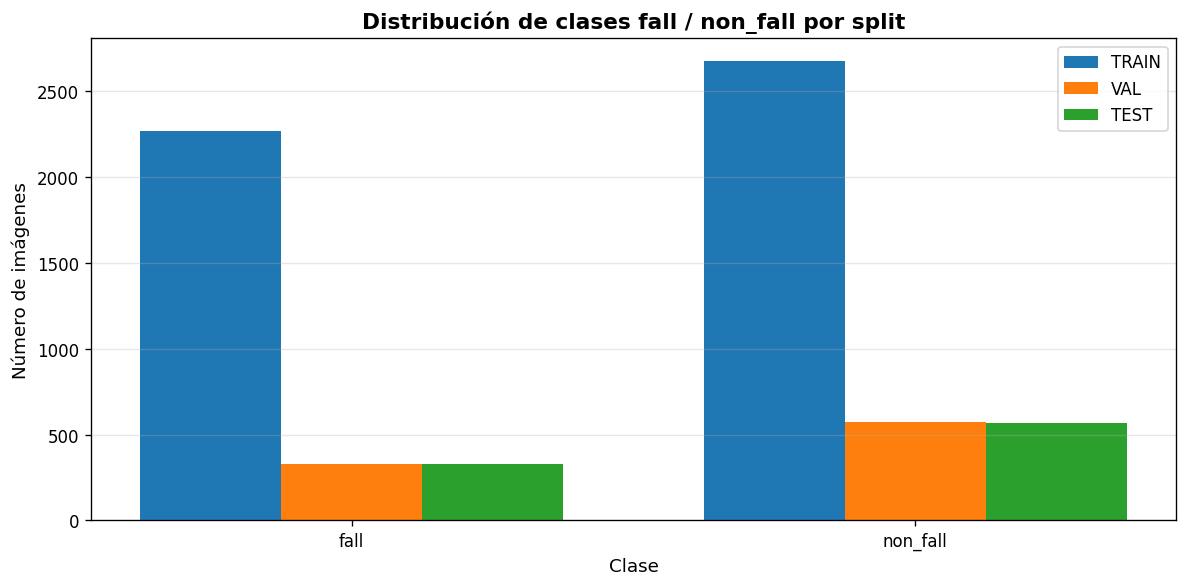

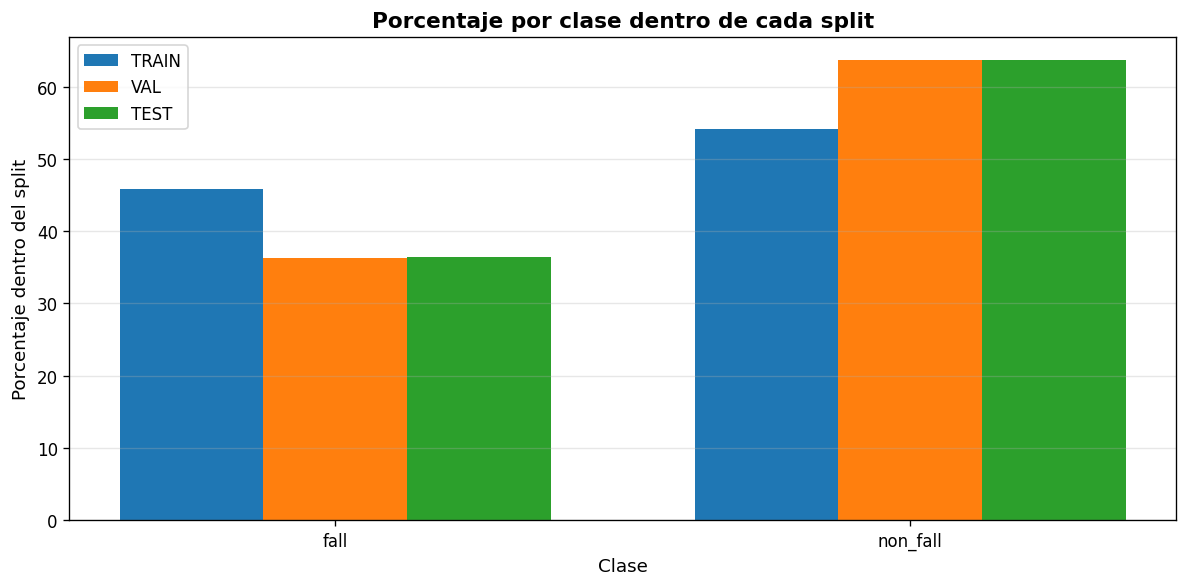


📦 REVISIÓN DE BOUNDING BOXES
split class_name  n_labels  area_media  area_mediana  pct_bbox_casi_completa  pct_bbox_valida
 test       fall       334      0.1073        0.0941                    0.00            100.0
 test   non_fall       582      0.1001        0.0833                    0.00            100.0
train       fall      2349      0.1110        0.0957                    0.21            100.0
train   non_fall      2705      0.1043        0.0847                    0.00            100.0
  val       fall       331      0.1048        0.0937                    0.00            100.0
  val   non_fall       586      0.1015        0.0801                    0.00            100.0

Interpretación:
  - pct_bbox_valida debe estar cerca de 100%.
  - area_media indica qué proporción de la imagen ocupa la bbox.
  - bbox_casi_completa no necesariamente es mala, pero debes saber si el dataset etiqueta la persona, la caída o casi toda la escena.


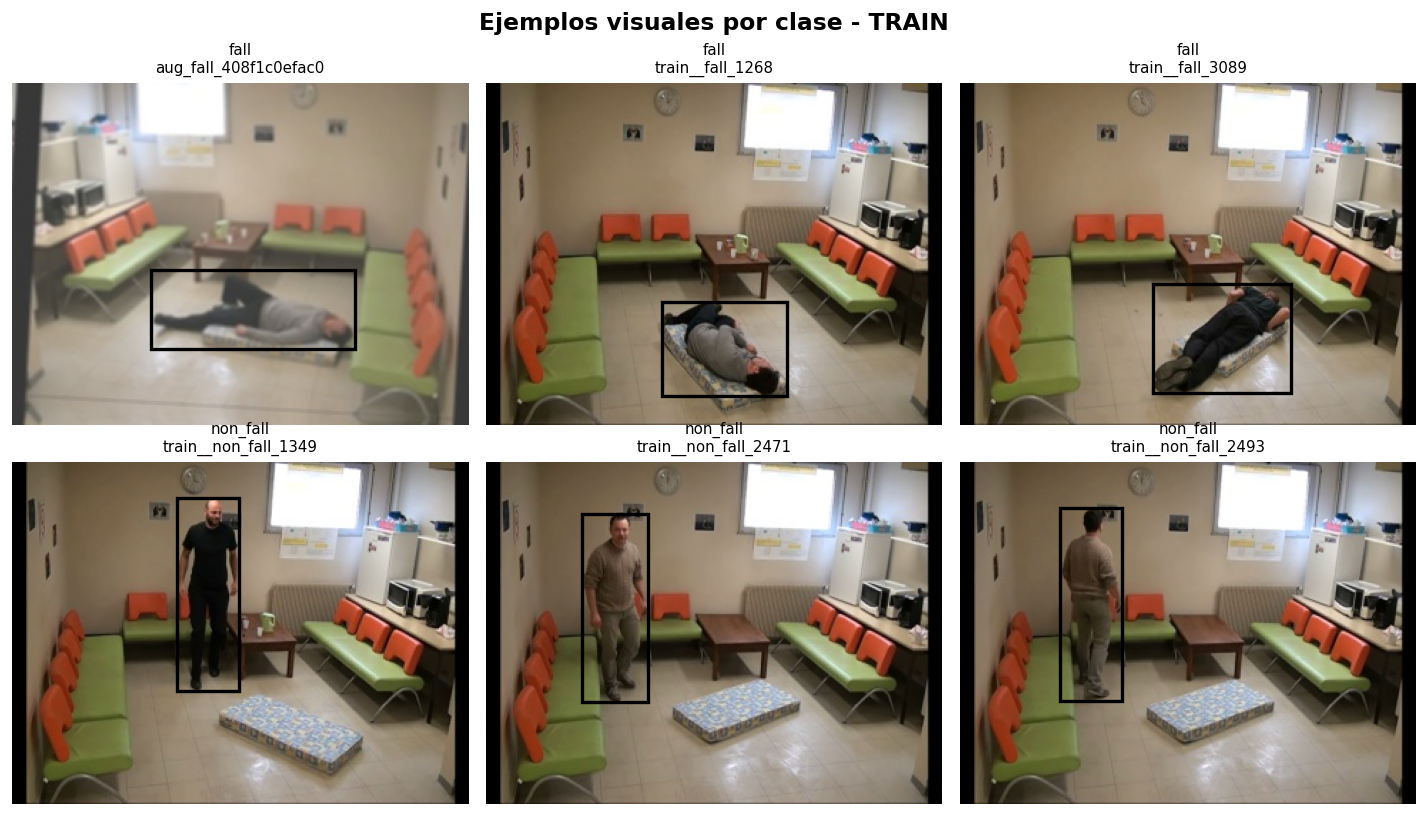

📸 Ejemplos guardados en: /content/eda_ejemplos_caidas_train.png

✅ DIAGNÓSTICO FINAL
Resumen esperado para tu trabajo:
  - Cada imagen debe tener una clase válida: fall o non_fall.
  - Las bboxes deben estar normalizadas en formato YOLO.
  - Para detección, la bbox sí importa: debería cubrir correctamente el sujeto o la región relevante.
  - Si las bboxes cubren casi toda la imagen, el modelo puede comportarse más como clasificador que como detector localizado.

⚠️ Problemas encontrados:
  - train: hay 467 archivos label vacíos.
  - train: hay 467 imágenes sin clase válida.
  - train: hay 12 imágenes con múltiples clases.
  - val: hay 100 archivos label vacíos.
  - val: hay 100 imágenes sin clase válida.
  - val: hay 2 imágenes con múltiples clases.
  - test: hay 100 archivos label vacíos.
  - test: hay 100 imágenes sin clase válida.
  - test: hay 5 imágenes con múltiples clases.

Archivos generados:
  /content/eda_caidas_distribucion.png
  /content/eda_caidas_porcentaje.png
  /content

In [11]:
# ============================================================
# CELDA 6 – Análisis del dataset de CAÍDAS / NO CAÍDAS
#
# Dataset:
#   baokhang9826_YOLO redistribuido 70 / 15 / 15
#
# Formato YOLO esperado:
#   class_id cx cy w h
#
# Orden de clases esperado según data.yaml:
#   0 fall
#   1 non_fall
# ============================================================

import gc
import cv2
import random
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm.auto import tqdm

# ------------------------------------------------------------
# 1. Rutas y configuración
# ------------------------------------------------------------

YOLO = Path("/content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15")
DATA_YAML = YOLO / "data.yaml"

SPLITS = ["train", "val", "test"]

IMG_EXTS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp",
    ".JPG", ".JPEG", ".PNG", ".BMP", ".WEBP"
}

print("=" * 80)
print("📦 ANÁLISIS DEL DATASET DE CAÍDAS / NO CAÍDAS")
print("=" * 80)

print(f"📁 YOLO      : {YOLO}")
print(f"📄 data.yaml : {DATA_YAML}")

if not YOLO.exists():
    raise FileNotFoundError(f"No existe la carpeta YOLO:\n{YOLO}")

# ------------------------------------------------------------
# 2. Leer clases desde data.yaml
# ------------------------------------------------------------

def normalizar_names(names):
    """
    Convierte names del data.yaml a lista.
    Soporta:
      names: ['fall', 'non_fall']
      names: {0: 'fall', 1: 'non_fall'}
    """

    if names is None:
        return None

    if isinstance(names, list):
        return names

    if isinstance(names, dict):
        try:
            return [names[k] for k in sorted(names, key=lambda x: int(x))]
        except Exception:
            return list(names.values())

    return None


CLASES_DEFAULT = ["fall", "non_fall"]

if DATA_YAML.exists():
    with open(DATA_YAML, "r", encoding="utf-8") as f:
        ydata = yaml.safe_load(f)

    CLASS_NAMES = normalizar_names(ydata.get("names"))

    if CLASS_NAMES is None:
        CLASS_NAMES = CLASES_DEFAULT
        print("⚠️ data.yaml existe, pero no trae clases válidas.")
        print(f"   Usando clases por defecto: {CLASS_NAMES}")

else:
    CLASS_NAMES = CLASES_DEFAULT
    print("⚠️ No se encontró data.yaml.")
    print(f"   Usando clases por defecto: {CLASS_NAMES}")

NUM_CLASSES = len(CLASS_NAMES)

print("\n🏷️ Orden de clases usado:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {i}: {name}")

# ------------------------------------------------------------
# 3. Helpers
# ------------------------------------------------------------

def buscar_imagen(stem, img_dir):
    """
    Busca una imagen cuyo nombre base coincida con el stem del label.
    """

    for ext in IMG_EXTS:
        p = img_dir / f"{stem}{ext}"
        if p.exists():
            return p

    return None


def leer_label_yolo(path):
    """
    Lee un archivo .txt YOLO.
    Retorna lista de tuplas:
      (class_id, cx, cy, w, h)
    """

    filas = []

    try:
        with open(path, "r", encoding="utf-8", errors="ignore") as fh:
            for line in fh:
                parts = line.strip().split()

                if len(parts) != 5:
                    continue

                try:
                    cid = int(float(parts[0]))
                    cx = float(parts[1])
                    cy = float(parts[2])
                    bw = float(parts[3])
                    bh = float(parts[4])

                    filas.append((cid, cx, cy, bw, bh))

                except ValueError:
                    continue

    except Exception:
        pass

    return filas


def leer_split_caidas(split):
    """
    Lee imágenes y labels de un split.

    Devuelve:
      df_labels: una fila por bbox/label
      df_imgs: una fila por imagen/label file
    """

    img_dir = YOLO / "images" / split
    lbl_dir = YOLO / "labels" / split

    filas_labels = []
    filas_imgs = []

    if not img_dir.exists():
        print(f"⚠️ No existe carpeta de imágenes: {img_dir}")
        return pd.DataFrame(), pd.DataFrame()

    if not lbl_dir.exists():
        print(f"⚠️ No existe carpeta de labels: {lbl_dir}")
        return pd.DataFrame(), pd.DataFrame()

    labels = sorted([
        p for p in lbl_dir.iterdir()
        if p.is_file() and p.suffix.lower() == ".txt"
    ])

    for lbl_path in tqdm(labels, desc=f"Leyendo {split}", leave=False):

        stem = lbl_path.stem
        img_path = buscar_imagen(stem, img_dir)

        bboxes = leer_label_yolo(lbl_path)

        tiene_img = img_path is not None

        clases = [
            bb[0]
            for bb in bboxes
            if 0 <= bb[0] < NUM_CLASSES
        ]

        clases_unicas = sorted(set(clases))

        filas_imgs.append({
            "split": split,
            "stem": stem,
            "label_path": str(lbl_path),
            "image_path": str(img_path) if img_path else None,
            "tiene_imagen": tiene_img,
            "n_labels": len(bboxes),
            "n_clases_validas": len(clases),
            "clases_unicas": clases_unicas,
            "n_clases_unicas": len(clases_unicas),
            "class_id_principal": clases_unicas[0] if len(clases_unicas) == 1 else np.nan,
            "class_name_principal": CLASS_NAMES[clases_unicas[0]] if len(clases_unicas) == 1 else None,
            "multi_clase": len(clases_unicas) > 1,
            "sin_clase_valida": len(clases_unicas) == 0,
            "label_vacio": len(bboxes) == 0
        })

        for cid, cx, cy, bw, bh in bboxes:

            clase_valida = 0 <= cid < NUM_CLASSES

            bbox_valida = (
                0 <= cx <= 1 and
                0 <= cy <= 1 and
                0 < bw <= 1 and
                0 < bh <= 1
            )

            area = bw * bh if bw > 0 and bh > 0 else np.nan

            # BBox muy grande, casi toda la imagen.
            # En detección de caídas esto no necesariamente es incorrecto,
            # pero conviene saber cuántas cajas cubren casi todo el frame.
            bbox_casi_completa = (
                0.40 <= cx <= 0.60 and
                0.40 <= cy <= 0.60 and
                bw >= 0.85 and
                bh >= 0.85
            )

            filas_labels.append({
                "split": split,
                "stem": stem,
                "image_path": str(img_path) if img_path else None,
                "label_path": str(lbl_path),
                "class_id": cid,
                "class_name": CLASS_NAMES[cid] if clase_valida else "INVALIDA",
                "cx": cx,
                "cy": cy,
                "bw": bw,
                "bh": bh,
                "area": area,
                "bbox_valida": bbox_valida,
                "bbox_casi_completa": bbox_casi_completa,
                "clase_valida": clase_valida,
                "tiene_imagen": tiene_img
            })

    df_labels = pd.DataFrame(filas_labels)
    df_imgs = pd.DataFrame(filas_imgs)

    return df_labels, df_imgs

# ------------------------------------------------------------
# 4. Lectura completa del dataset
# ------------------------------------------------------------

print("\n📦 Leyendo dataset de caídas / no caídas...")

dfs_labels = {}
dfs_imgs = {}

for split in SPLITS:

    df_l, df_i = leer_split_caidas(split)

    dfs_labels[split] = df_l
    dfs_imgs[split] = df_i

    print(
        f"  {split.upper():<6} "
        f"labels={len(df_l):,}  "
        f"imágenes_con_label={len(df_i):,}"
    )

df_labels_all = pd.concat(dfs_labels.values(), ignore_index=True)
df_imgs_all = pd.concat(dfs_imgs.values(), ignore_index=True)

# ------------------------------------------------------------
# 5. Revisión de consistencia del dataset
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("🧪 REVISIÓN DE CONSISTENCIA DEL DATASET")
print("=" * 80)

for split in SPLITS:

    df_i = dfs_imgs[split]
    df_l = dfs_labels[split]

    if df_i.empty:
        print(f"\n{split.upper()}: sin datos.")
        continue

    total_imgs_label = len(df_i)
    sin_img = (~df_i["tiene_imagen"]).sum()
    labels_vacios = df_i["label_vacio"].sum()
    sin_clase = df_i["sin_clase_valida"].sum()
    multi_clase = df_i["multi_clase"].sum()

    labels_invalidos = 0
    bboxes_invalidas = 0
    cajas_casi_completas = 0
    pct_cajas_casi_completas = 0

    if not df_l.empty:
        labels_invalidos = (~df_l["clase_valida"]).sum()
        bboxes_invalidas = (~df_l["bbox_valida"]).sum()
        cajas_casi_completas = df_l["bbox_casi_completa"].sum()
        pct_cajas_casi_completas = 100 * cajas_casi_completas / len(df_l)

    print(f"\n📁 {split.upper()}")
    print(f"  Imágenes con archivo label        : {total_imgs_label:,}")
    print(f"  Labels / bboxes totales           : {len(df_l):,}")
    print(f"  Labels sin imagen correspondiente : {sin_img:,}")
    print(f"  Archivos label vacíos             : {labels_vacios:,}")
    print(f"  Imágenes sin clase válida         : {sin_clase:,}")
    print(f"  Imágenes con múltiples clases     : {multi_clase:,}")
    print(f"  Labels con class_id inválido      : {labels_invalidos:,}")
    print(f"  BBoxes fuera de rango YOLO        : {bboxes_invalidas:,}")
    print(f"  BBoxes casi imagen completa       : {cajas_casi_completas:,} ({pct_cajas_casi_completas:.2f}%)")

    if bboxes_invalidas == 0 and labels_invalidos == 0 and sin_img == 0:
        print("  ✅ Estructura general consistente.")
    else:
        print("  ⚠️ Hay aspectos que conviene revisar.")

# ------------------------------------------------------------
# 6. Distribución de clases por split
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("📊 DISTRIBUCIÓN DE CLASES POR SPLIT")
print("=" * 80)

resumen = []

for split in SPLITS:

    df = dfs_imgs[split].copy()

    # Para este resumen contamos imágenes con una única clase válida.
    # Si una imagen tiene varias bboxes de la misma clase, cuenta una vez.
    df_valid = df[
        (df["tiene_imagen"] == True) &
        (df["sin_clase_valida"] == False) &
        (df["multi_clase"] == False)
    ].copy()

    conteo = df_valid["class_id_principal"].value_counts().to_dict()

    for cid, cname in enumerate(CLASS_NAMES):
        resumen.append({
            "split": split,
            "class_id": cid,
            "class_name": cname,
            "n_imagenes": int(conteo.get(cid, 0))
        })

df_resumen = pd.DataFrame(resumen)

tabla = df_resumen.pivot(
    index="class_name",
    columns="split",
    values="n_imagenes"
).fillna(0).astype(int)

tabla = tabla.reindex(CLASS_NAMES)

tabla["total"] = tabla.sum(axis=1)

print(tabla.to_string())

# ------------------------------------------------------------
# 7. Porcentaje por clase dentro de cada split
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("📊 PORCENTAJE POR CLASE DENTRO DE CADA SPLIT")
print("=" * 80)

tabla_pct = tabla[SPLITS].copy()

for split in SPLITS:

    total_split = tabla_pct[split].sum()

    if total_split > 0:
        tabla_pct[split] = (tabla_pct[split] / total_split * 100).round(2)
    else:
        tabla_pct[split] = 0

print(tabla_pct.to_string())

# ------------------------------------------------------------
# 8. Gráfico: distribución de clases por split
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(NUM_CLASSES)
width = 0.25

for idx, split in enumerate(SPLITS):

    valores = [
        int(
            df_resumen[
                (df_resumen["split"] == split) &
                (df_resumen["class_id"] == cid)
            ]["n_imagenes"].values[0]
        )
        for cid in range(NUM_CLASSES)
    ]

    ax.bar(
        x + (idx - 1) * width,
        valores,
        width,
        label=split.upper()
    )

ax.set_title("Distribución de clases fall / non_fall por split", fontweight="bold")
ax.set_xlabel("Clase")
ax.set_ylabel("Número de imágenes")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

OUT_DIST = "/content/eda_caidas_distribucion.png"

plt.savefig(
    OUT_DIST,
    dpi=120,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 9. Gráfico: porcentaje por clase
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

for idx, split in enumerate(SPLITS):

    valores = tabla_pct[split].values

    ax.bar(
        x + (idx - 1) * width,
        valores,
        width,
        label=split.upper()
    )

ax.set_title("Porcentaje por clase dentro de cada split", fontweight="bold")
ax.set_xlabel("Clase")
ax.set_ylabel("Porcentaje dentro del split")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

OUT_PCT = "/content/eda_caidas_porcentaje.png"

plt.savefig(
    OUT_PCT,
    dpi=120,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 10. Revisión de bounding boxes por clase
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("📦 REVISIÓN DE BOUNDING BOXES")
print("=" * 80)

if not df_labels_all.empty:

    resumen_bbox = df_labels_all.groupby(["split", "class_name"]).agg(
        n_labels=("class_id", "count"),
        area_media=("area", "mean"),
        area_mediana=("area", "median"),
        pct_bbox_casi_completa=("bbox_casi_completa", lambda x: 100 * x.mean()),
        pct_bbox_valida=("bbox_valida", lambda x: 100 * x.mean())
    ).reset_index()

    resumen_bbox["area_media"] = resumen_bbox["area_media"].round(4)
    resumen_bbox["area_mediana"] = resumen_bbox["area_mediana"].round(4)
    resumen_bbox["pct_bbox_casi_completa"] = resumen_bbox["pct_bbox_casi_completa"].round(2)
    resumen_bbox["pct_bbox_valida"] = resumen_bbox["pct_bbox_valida"].round(2)

    print(resumen_bbox.to_string(index=False))

    print("\nInterpretación:")
    print("  - pct_bbox_valida debe estar cerca de 100%.")
    print("  - area_media indica qué proporción de la imagen ocupa la bbox.")
    print("  - bbox_casi_completa no necesariamente es mala, pero debes saber si el dataset etiqueta la persona, la caída o casi toda la escena.")

else:
    print("No hay labels para analizar.")

# ------------------------------------------------------------
# 11. Visualizar ejemplos por clase
# ------------------------------------------------------------

def mostrar_ejemplos_por_clase(split="train", n_por_clase=3, dibujar_bbox=True):

    df = dfs_imgs[split].copy()

    df = df[
        (df["tiene_imagen"] == True) &
        (df["sin_clase_valida"] == False) &
        (df["multi_clase"] == False)
    ].copy()

    if df.empty:
        print(f"⚠️ No hay ejemplos válidos en {split}.")
        return

    fig, axes = plt.subplots(
        NUM_CLASSES,
        n_por_clase,
        figsize=(4 * n_por_clase, 3.5 * NUM_CLASSES)
    )

    if NUM_CLASSES == 1:
        axes = np.array([axes])

    if NUM_CLASSES == 2 and n_por_clase == 1:
        axes = axes.reshape(NUM_CLASSES, 1)

    for cid, cname in enumerate(CLASS_NAMES):

        muestras = df[df["class_id_principal"] == cid]

        if len(muestras) == 0:
            for j in range(n_por_clase):
                axes[cid, j].axis("off")
            continue

        muestras = muestras.sample(
            min(n_por_clase, len(muestras)),
            random_state=42
        )

        muestras = muestras.to_dict("records")

        for j in range(n_por_clase):

            ax = axes[cid, j]
            ax.axis("off")

            if j >= len(muestras):
                continue

            row = muestras[j]

            img_path = row["image_path"]
            stem = row["stem"]

            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            h, w = img.shape[:2]

            ax.imshow(img)
            ax.set_title(f"{cname}\n{stem}", fontsize=9)

            if dibujar_bbox:

                lbl_path = Path(row["label_path"])
                bbs = leer_label_yolo(lbl_path)

                for bb in bbs:

                    bb_cid, cx, cy, bw, bh = bb

                    if bb_cid != cid:
                        continue

                    x1 = int((cx - bw / 2) * w)
                    y1 = int((cy - bh / 2) * h)
                    x2 = int((cx + bw / 2) * w)
                    y2 = int((cy + bh / 2) * h)

                    x1 = max(0, min(w - 1, x1))
                    y1 = max(0, min(h - 1, y1))
                    x2 = max(0, min(w - 1, x2))
                    y2 = max(0, min(h - 1, y2))

                    rect = plt.Rectangle(
                        (x1, y1),
                        x2 - x1,
                        y2 - y1,
                        fill=False,
                        linewidth=2
                    )

                    ax.add_patch(rect)

    plt.suptitle(
        f"Ejemplos visuales por clase - {split.upper()}",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()

    OUT_EX = f"/content/eda_ejemplos_caidas_{split}.png"

    plt.savefig(
        OUT_EX,
        dpi=120,
        bbox_inches="tight"
    )

    plt.show()

    print(f"📸 Ejemplos guardados en: {OUT_EX}")


mostrar_ejemplos_por_clase(
    split="train",
    n_por_clase=3,
    dibujar_bbox=True
)

# ------------------------------------------------------------
# 12. Diagnóstico final
# ------------------------------------------------------------

print("\n" + "=" * 80)
print("✅ DIAGNÓSTICO FINAL")
print("=" * 80)

problemas = []

for split in SPLITS:

    df_i = dfs_imgs[split]
    df_l = dfs_labels[split]

    if df_i.empty:
        problemas.append(f"{split}: no tiene datos.")
        continue

    sin_img = (~df_i["tiene_imagen"]).sum()
    sin_clase = df_i["sin_clase_valida"].sum()
    multi_clase = df_i["multi_clase"].sum()
    labels_vacios = df_i["label_vacio"].sum()

    if sin_img > 0:
        problemas.append(f"{split}: hay {sin_img} labels sin imagen.")

    if labels_vacios > 0:
        problemas.append(f"{split}: hay {labels_vacios} archivos label vacíos.")

    if sin_clase > 0:
        problemas.append(f"{split}: hay {sin_clase} imágenes sin clase válida.")

    if multi_clase > 0:
        problemas.append(f"{split}: hay {multi_clase} imágenes con múltiples clases.")

    if not df_l.empty:
        invalidas = (~df_l["clase_valida"]).sum()
        bboxes_invalidas = (~df_l["bbox_valida"]).sum()

        if invalidas > 0:
            problemas.append(f"{split}: hay {invalidas} labels con class_id inválido.")

        if bboxes_invalidas > 0:
            problemas.append(f"{split}: hay {bboxes_invalidas} bboxes fuera de rango YOLO.")

print("Resumen esperado para tu trabajo:")
print("  - Cada imagen debe tener una clase válida: fall o non_fall.")
print("  - Las bboxes deben estar normalizadas en formato YOLO.")
print("  - Para detección, la bbox sí importa: debería cubrir correctamente el sujeto o la región relevante.")
print("  - Si las bboxes cubren casi toda la imagen, el modelo puede comportarse más como clasificador que como detector localizado.")

if problemas:

    print("\n⚠️ Problemas encontrados:")

    for p in problemas:
        print(f"  - {p}")

else:

    print("\n✅ No se encontraron problemas graves de estructura.")

print("\nArchivos generados:")
print(f"  {OUT_DIST}")
print(f"  {OUT_PCT}")
print("  /content/eda_ejemplos_caidas_train.png")

gc.collect()

print("\n✅ Análisis del dataset de caídas completado.")

🔍 Sección 7 – Validación de Integridad del Dataset

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 CONFIGURACIÓN DEL DATASET
Ruta YOLO: /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15
data.yaml: /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15/data.yaml
¿Existe ruta YOLO?: True

Estructura esperada:
 images/train: True
 images/val  : True
 images/test : True
 labels/train: True
 labels/val  : True
 labels/test : True

🏷️ Clases:
   0: fall
   1: non_fall

🔍 VALIDACIÓN DE INTEGRIDAD POR SPLIT

🔹 TRAIN
   📂 Carpeta imágenes : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15/images/train
   📂 Carpeta labels   : /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15/labels/train
   📸 Imágenes                  : 5,419
   🏷️ Labels                    : 5,419
   ✅ Coincidencias             : 5,419
   ✅ Imágenes sin label        : 0
   ✅ Labels sin imagen        : 0
   ⚠️ Labels vacíos       

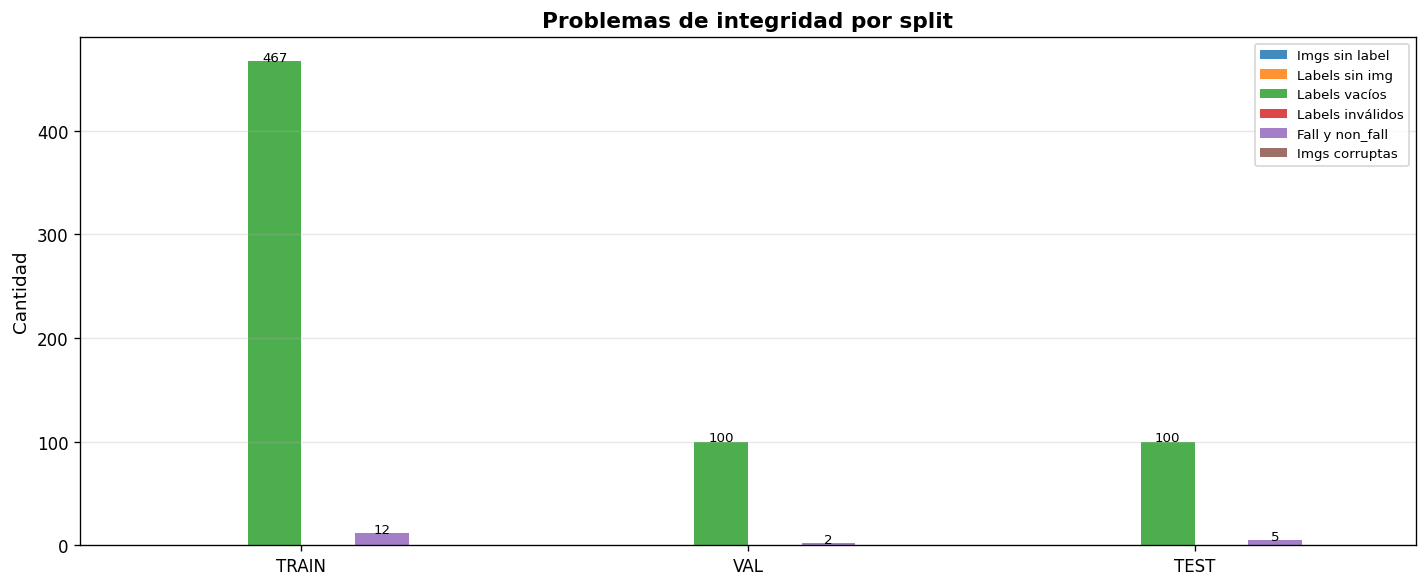

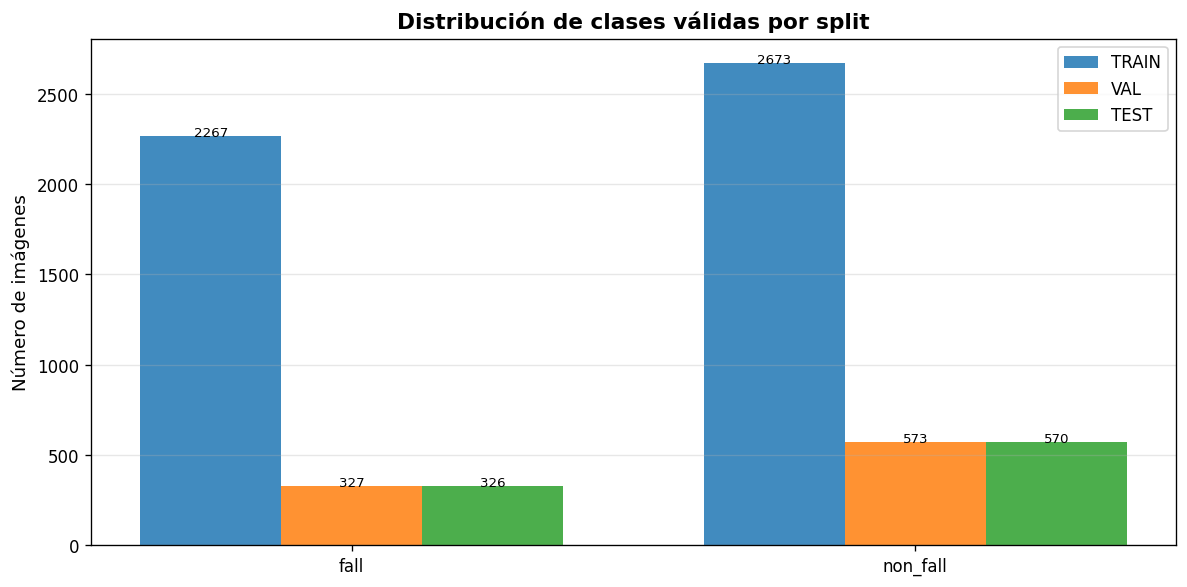


📄 Reporte de problemas guardado en:
   /content/reporte_problemas_integridad_caidas.csv

✅ DIAGNÓSTICO FINAL PARA DATASET DE CAÍDAS
⚠️ Se encontraron puntos a revisar:
   - train: 467 labels vacíos
   - train: 12 imágenes contienen fall y non_fall
   - val: 100 labels vacíos
   - val: 2 imágenes contienen fall y non_fall
   - test: 100 labels vacíos
   - test: 5 imágenes contienen fall y non_fall

Interpretación para tu trabajo:

  - Cada imagen debe tener su label correspondiente.
  - Cada label debe estar en formato YOLO:
        class_id cx cy w h

  - Para este dataset, los class_id válidos son:
        0 fall
        1 non_fall

  - Si una imagen tiene más de una bbox de la MISMA clase, no necesariamente es error.
    Puede ocurrir si hay varias personas o varias regiones etiquetadas.

  - Si una imagen contiene simultáneamente fall y non_fall, sí conviene revisarla,
    porque puede confundir el entrenamiento si la escena no está claramente definida.

  - Los labels vacíos norma

In [12]:
# ============================================================
# CELDA 7 – Validación de integridad para dataset de CAÍDAS
# Dataset:
#   baokhang9826_YOLO / YOLO_70_15_15
#
# Ruta esperada:
#   /content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15
#
# Formato YOLO esperado:
#   class_id cx cy w h
#
# Orden de clases esperado:
#   0 fall
#   1 non_fall
# ============================================================

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import yaml

# ------------------------------------------------------------
# 0. Montar Google Drive si estás en Colab
# ------------------------------------------------------------

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception:
    print("ℹ️ No se montó Drive automáticamente. Si ya está montado, no hay problema.")

# ------------------------------------------------------------
# 1. Configuración del dataset
# ------------------------------------------------------------

YOLO = Path("/content/drive/MyDrive/TFM/datasets/baokhang9826_YOLO/YOLO_70_15_15")
DATA_YAML = YOLO / "data.yaml"

SPLITS = ["train", "val", "test"]

IMG_EXTS = {
    ".jpg", ".jpeg", ".png", ".bmp", ".webp",
    ".JPG", ".JPEG", ".PNG", ".BMP", ".WEBP"
}

# ------------------------------------------------------------
# 2. Leer clases desde data.yaml
# ------------------------------------------------------------

def normalizar_names(names):
    """
    Convierte names del data.yaml a lista.
    Soporta:
      names: ['fall', 'non_fall']
      names: {0: 'fall', 1: 'non_fall'}
    """
    if names is None:
        return None

    if isinstance(names, list):
        return names

    if isinstance(names, dict):
        try:
            return [names[k] for k in sorted(names, key=lambda x: int(x))]
        except Exception:
            return list(names.values())

    return None


CLASES_DEFAULT = ["fall", "non_fall"]

if DATA_YAML.exists():
    with open(DATA_YAML, "r", encoding="utf-8") as f:
        ydata = yaml.safe_load(f)

    CLASS_NAMES = normalizar_names(ydata.get("names"))

    if CLASS_NAMES is None:
        CLASS_NAMES = CLASES_DEFAULT
        print("⚠️ data.yaml existe, pero no trae clases válidas.")
        print(f"   Usando clases por defecto: {CLASS_NAMES}")
else:
    CLASS_NAMES = CLASES_DEFAULT
    print("⚠️ No se encontró data.yaml.")
    print(f"   Usando clases por defecto: {CLASS_NAMES}")

NUM_CLASSES = len(CLASS_NAMES)

print("=" * 70)
print("📁 CONFIGURACIÓN DEL DATASET")
print("=" * 70)
print("Ruta YOLO:", YOLO)
print("data.yaml:", DATA_YAML)
print("¿Existe ruta YOLO?:", YOLO.exists())

print("\nEstructura esperada:")
print(" images/train:", (YOLO / "images" / "train").exists())
print(" images/val  :", (YOLO / "images" / "val").exists())
print(" images/test :", (YOLO / "images" / "test").exists())
print(" labels/train:", (YOLO / "labels" / "train").exists())
print(" labels/val  :", (YOLO / "labels" / "val").exists())
print(" labels/test :", (YOLO / "labels" / "test").exists())

print("\n🏷️ Clases:")
for i, c in enumerate(CLASS_NAMES):
    print(f"   {i}: {c}")

# ------------------------------------------------------------
# 3. Funciones auxiliares
# ------------------------------------------------------------

def leer_label_yolo(label_path):
    """
    Lee un archivo .txt en formato YOLO:
        class_id cx cy w h

    Devuelve una lista de registros con estado de validez.
    """

    registros = []

    try:
        with open(label_path, "r", encoding="utf-8", errors="ignore") as fh:
            for line_num, line in enumerate(fh, start=1):
                parts = line.strip().split()

                if len(parts) == 0:
                    continue

                if len(parts) != 5:
                    registros.append({
                        "class_id": None,
                        "cx": None,
                        "cy": None,
                        "bw": None,
                        "bh": None,
                        "linea": line_num,
                        "valida": False,
                        "motivo": "formato_incorrecto"
                    })
                    continue

                try:
                    class_id = int(float(parts[0]))
                    cx = float(parts[1])
                    cy = float(parts[2])
                    bw = float(parts[3])
                    bh = float(parts[4])

                    clase_valida = 0 <= class_id < NUM_CLASSES

                    coords_validas = (
                        0 <= cx <= 1 and
                        0 <= cy <= 1 and
                        0 < bw <= 1 and
                        0 < bh <= 1
                    )

                    if not clase_valida:
                        motivo = "class_id_invalido"
                    elif not coords_validas:
                        motivo = "coordenadas_invalidas"
                    else:
                        motivo = "ok"

                    registros.append({
                        "class_id": class_id,
                        "cx": cx,
                        "cy": cy,
                        "bw": bw,
                        "bh": bh,
                        "linea": line_num,
                        "valida": clase_valida and coords_validas,
                        "motivo": motivo
                    })

                except ValueError:
                    registros.append({
                        "class_id": None,
                        "cx": None,
                        "cy": None,
                        "bw": None,
                        "bh": None,
                        "linea": line_num,
                        "valida": False,
                        "motivo": "valor_no_numerico"
                    })

    except Exception:
        registros.append({
            "class_id": None,
            "cx": None,
            "cy": None,
            "bw": None,
            "bh": None,
            "linea": None,
            "valida": False,
            "motivo": "error_lectura"
        })

    return registros


def obtener_stems_imagenes(img_dir):
    if not img_dir.exists():
        return set()

    return {
        p.stem
        for p in img_dir.iterdir()
        if p.is_file() and p.suffix in IMG_EXTS
    }


def obtener_stems_labels(lbl_dir):
    if not lbl_dir.exists():
        return set()

    return {
        p.stem
        for p in lbl_dir.iterdir()
        if p.is_file() and p.suffix.lower() == ".txt"
    }


def verificar_imagen_corrupta(path_img):
    """
    Devuelve True si la imagen parece corrupta.
    """

    try:
        with Image.open(path_img) as im:
            im.verify()
        return False
    except Exception:
        return True

# ------------------------------------------------------------
# 4. Validación principal
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("🔍 VALIDACIÓN DE INTEGRIDAD POR SPLIT")
print("=" * 70)

reporte_integridad = {}
filas_detalle = []

for split in SPLITS:

    img_dir = YOLO / "images" / split
    lbl_dir = YOLO / "labels" / split

    imgs_stems = obtener_stems_imagenes(img_dir)
    lbls_stems = obtener_stems_labels(lbl_dir)

    sin_label = imgs_stems - lbls_stems
    sin_imagen = lbls_stems - imgs_stems
    coinciden = imgs_stems & lbls_stems

    labels_vacios = 0
    labels_invalidos = 0
    imagenes_multi_clase = 0
    imagenes_sin_clase_valida = 0
    imagenes_con_mas_de_un_label = 0
    imagenes_con_fall_y_non_fall = 0

    clases_por_split = {i: 0 for i in range(NUM_CLASSES)}

    ejemplos_sin_label = sorted(list(sin_label))[:5]
    ejemplos_sin_imagen = sorted(list(sin_imagen))[:5]
    ejemplos_labels_vacios = []
    ejemplos_invalidos = []
    ejemplos_multi_clase = []
    ejemplos_corruptos = []

    # --------------------------------------------------------
    # Revisar labels que tienen imagen correspondiente
    # --------------------------------------------------------

    for stem in coinciden:

        lbl_path = lbl_dir / f"{stem}.txt"

        if lbl_path.stat().st_size == 0:
            labels_vacios += 1
            imagenes_sin_clase_valida += 1

            if len(ejemplos_labels_vacios) < 5:
                ejemplos_labels_vacios.append(stem)

            filas_detalle.append({
                "split": split,
                "stem": stem,
                "problema": "label_vacio"
            })

            continue

        registros = leer_label_yolo(lbl_path)

        registros_validos = [r for r in registros if r["valida"]]
        registros_invalidos = [r for r in registros if not r["valida"]]

        if len(registros_invalidos) > 0:
            labels_invalidos += len(registros_invalidos)

            if len(ejemplos_invalidos) < 5:
                ejemplos_invalidos.append(stem)

            filas_detalle.append({
                "split": split,
                "stem": stem,
                "problema": "label_invalido"
            })

        clases_validas = [
            r["class_id"]
            for r in registros_validos
        ]

        clases_unicas = sorted(set(clases_validas))

        if len(clases_validas) == 0:
            imagenes_sin_clase_valida += 1

            filas_detalle.append({
                "split": split,
                "stem": stem,
                "problema": "sin_clase_valida"
            })

        if len(clases_validas) > 1:
            imagenes_con_mas_de_un_label += 1

        if len(clases_unicas) > 1:
            imagenes_multi_clase += 1
            imagenes_con_fall_y_non_fall += 1

            if len(ejemplos_multi_clase) < 5:
                ejemplos_multi_clase.append(stem)

            filas_detalle.append({
                "split": split,
                "stem": stem,
                "problema": "multiples_clases_en_misma_imagen"
            })

        # Para el resumen por imagen:
        # Si una imagen tiene una sola clase válida, cuenta una vez para esa clase.
        # Si tiene varias bboxes de la misma clase, sigue contando una sola imagen.
        if len(clases_unicas) == 1:
            clases_por_split[clases_unicas[0]] += 1

    # --------------------------------------------------------
    # Revisar imágenes corruptas
    # --------------------------------------------------------

    corruptos = 0

    if img_dir.exists():
        for p in img_dir.iterdir():

            if not p.is_file():
                continue

            if p.suffix not in IMG_EXTS:
                continue

            if verificar_imagen_corrupta(p):
                corruptos += 1

                if len(ejemplos_corruptos) < 5:
                    ejemplos_corruptos.append(p.name)

                filas_detalle.append({
                    "split": split,
                    "stem": p.stem,
                    "problema": "imagen_corrupta"
                })

    reporte_integridad[split] = {
        "total_imgs": len(imgs_stems),
        "total_lbls": len(lbls_stems),
        "coincidencias": len(coinciden),
        "sin_label": len(sin_label),
        "sin_imagen": len(sin_imagen),
        "labels_vacios": labels_vacios,
        "labels_invalidos": labels_invalidos,
        "imagenes_sin_clase_valida": imagenes_sin_clase_valida,
        "imagenes_con_mas_de_un_label": imagenes_con_mas_de_un_label,
        "imagenes_multi_clase": imagenes_multi_clase,
        "imagenes_con_fall_y_non_fall": imagenes_con_fall_y_non_fall,
        "corruptos": corruptos,
        "clases": clases_por_split,
        "ejemplos_sin_label": ejemplos_sin_label,
        "ejemplos_sin_imagen": ejemplos_sin_imagen,
        "ejemplos_labels_vacios": ejemplos_labels_vacios,
        "ejemplos_invalidos": ejemplos_invalidos,
        "ejemplos_multi_clase": ejemplos_multi_clase,
        "ejemplos_corruptos": ejemplos_corruptos
    }

    r = reporte_integridad[split]

    print(f"\n🔹 {split.upper()}")

    print(f"   📂 Carpeta imágenes : {img_dir}")
    print(f"   📂 Carpeta labels   : {lbl_dir}")

    print(f"   📸 Imágenes                  : {r['total_imgs']:,}")
    print(f"   🏷️ Labels                    : {r['total_lbls']:,}")
    print(f"   ✅ Coincidencias             : {r['coincidencias']:,}")
    print(f"   {'⚠️' if r['sin_label'] > 0 else '✅'} Imágenes sin label        : {r['sin_label']:,}")
    print(f"   {'⚠️' if r['sin_imagen'] > 0 else '✅'} Labels sin imagen        : {r['sin_imagen']:,}")
    print(f"   {'⚠️' if r['labels_vacios'] > 0 else '✅'} Labels vacíos          : {r['labels_vacios']:,}")
    print(f"   {'⚠️' if r['labels_invalidos'] > 0 else '✅'} Labels inválidos       : {r['labels_invalidos']:,}")
    print(f"   {'⚠️' if r['imagenes_sin_clase_valida'] > 0 else '✅'} Imgs sin clase válida : {r['imagenes_sin_clase_valida']:,}")
    print(f"   {'⚠️' if r['imagenes_multi_clase'] > 0 else '✅'} Imgs con fall y non_fall: {r['imagenes_multi_clase']:,}")
    print(f"   {'⚠️' if r['imagenes_con_mas_de_un_label'] > 0 else '✅'} Imgs con >1 bbox       : {r['imagenes_con_mas_de_un_label']:,}")
    print(f"   {'❌' if r['corruptos'] > 0 else '✅'} Imágenes corruptas       : {r['corruptos']:,}")

    if r["ejemplos_sin_label"]:
        print(f"      Ejemplos imgs sin label  : {r['ejemplos_sin_label']}")

    if r["ejemplos_sin_imagen"]:
        print(f"      Ejemplos labels sin img  : {r['ejemplos_sin_imagen']}")

    if r["ejemplos_labels_vacios"]:
        print(f"      Ejemplos labels vacíos   : {r['ejemplos_labels_vacios']}")

    if r["ejemplos_invalidos"]:
        print(f"      Ejemplos labels inválidos: {r['ejemplos_invalidos']}")

    if r["ejemplos_multi_clase"]:
        print(f"      Ejemplos fall/non_fall en misma imagen: {r['ejemplos_multi_clase']}")

    if r["ejemplos_corruptos"]:
        print(f"      Ejemplos corruptas       : {r['ejemplos_corruptos']}")

# ------------------------------------------------------------
# 5. Tabla distribución de clases válidas
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("📊 DISTRIBUCIÓN DE CLASES VÁLIDAS")
print("=" * 70)

filas_dist = []

for split in SPLITS:

    clases = reporte_integridad[split]["clases"]

    for cid, cname in enumerate(CLASS_NAMES):
        filas_dist.append({
            "split": split,
            "class_id": cid,
            "class_name": cname,
            "n": clases[cid]
        })

df_dist = pd.DataFrame(filas_dist)

tabla_dist = df_dist.pivot(
    index="class_name",
    columns="split",
    values="n"
).fillna(0).astype(int)

tabla_dist = tabla_dist.reindex(CLASS_NAMES)
tabla_dist["total"] = tabla_dist.sum(axis=1)

print(tabla_dist.to_string())

# ------------------------------------------------------------
# 6. Porcentaje por split
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("📊 PORCENTAJE POR CLASE DENTRO DE CADA SPLIT")
print("=" * 70)

tabla_pct = tabla_dist[SPLITS].copy()

for split in SPLITS:

    total_split = tabla_pct[split].sum()

    if total_split > 0:
        tabla_pct[split] = (tabla_pct[split] / total_split * 100).round(2)
    else:
        tabla_pct[split] = 0

print(tabla_pct.to_string())

# ------------------------------------------------------------
# 7. Gráfica problemas de integridad
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

categorias = [
    "sin_label",
    "sin_imagen",
    "labels_vacios",
    "labels_invalidos",
    "imagenes_multi_clase",
    "corruptos"
]

etiquetas = [
    "Imgs sin label",
    "Labels sin img",
    "Labels vacíos",
    "Labels inválidos",
    "Fall y non_fall",
    "Imgs corruptas"
]

x = np.arange(len(SPLITS))
w = 0.12

for i, (cat, etiqueta) in enumerate(zip(categorias, etiquetas)):

    vals = [
        reporte_integridad[s][cat]
        for s in SPLITS
    ]

    bars = ax.bar(
        x + i * w - ((len(categorias) - 1) / 2) * w,
        vals,
        w,
        label=etiqueta,
        alpha=0.85
    )

    for bar in bars:
        if bar.get_height() > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                str(int(bar.get_height())),
                ha="center",
                fontsize=8
            )

ax.set_title("Problemas de integridad por split", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([s.upper() for s in SPLITS])
ax.set_ylabel("Cantidad")
ax.legend(loc="upper right", fontsize=8)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

OUT_INTEGRIDAD = "/content/eda_integridad_caidas.png"

plt.savefig(
    OUT_INTEGRIDAD,
    dpi=120,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 8. Gráfica distribución de clases válidas
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(NUM_CLASSES)
w = 0.25

for i, split in enumerate(SPLITS):

    vals = [
        reporte_integridad[split]["clases"][cid]
        for cid in range(NUM_CLASSES)
    ]

    bars = ax.bar(
        x + i * w - w,
        vals,
        w,
        label=split.upper(),
        alpha=0.85
    )

    for bar in bars:
        if bar.get_height() > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                str(int(bar.get_height())),
                ha="center",
                fontsize=8
            )

ax.set_title("Distribución de clases válidas por split", fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(CLASS_NAMES)
ax.set_ylabel("Número de imágenes")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()

OUT_DIST = "/content/eda_distribucion_caidas_validas.png"

plt.savefig(
    OUT_DIST,
    dpi=120,
    bbox_inches="tight"
)

plt.show()

# ------------------------------------------------------------
# 9. Guardar reporte de problemas
# ------------------------------------------------------------

df_problemas = pd.DataFrame(filas_detalle)

OUT_CSV = "/content/reporte_problemas_integridad_caidas.csv"

if len(df_problemas) > 0:
    df_problemas.to_csv(OUT_CSV, index=False)
    print("\n📄 Reporte de problemas guardado en:")
    print(f"   {OUT_CSV}")
else:
    print("\n✅ No se generó CSV de problemas porque no se encontraron problemas.")

# ------------------------------------------------------------
# 10. Diagnóstico final
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("✅ DIAGNÓSTICO FINAL PARA DATASET DE CAÍDAS")
print("=" * 70)

problemas_globales = []

for split in SPLITS:

    r = reporte_integridad[split]

    if r["sin_label"] > 0:
        problemas_globales.append(f"{split}: {r['sin_label']} imágenes sin label")

    if r["sin_imagen"] > 0:
        problemas_globales.append(f"{split}: {r['sin_imagen']} labels sin imagen")

    if r["labels_vacios"] > 0:
        problemas_globales.append(f"{split}: {r['labels_vacios']} labels vacíos")

    if r["labels_invalidos"] > 0:
        problemas_globales.append(f"{split}: {r['labels_invalidos']} labels inválidos")

    if r["imagenes_multi_clase"] > 0:
        problemas_globales.append(
            f"{split}: {r['imagenes_multi_clase']} imágenes contienen fall y non_fall"
        )

    if r["corruptos"] > 0:
        problemas_globales.append(f"{split}: {r['corruptos']} imágenes corruptas")

if problemas_globales:

    print("⚠️ Se encontraron puntos a revisar:")

    for p in problemas_globales:
        print(f"   - {p}")

else:

    print("✅ La estructura del dataset se ve consistente.")

print("""
Interpretación para tu trabajo:

  - Cada imagen debe tener su label correspondiente.
  - Cada label debe estar en formato YOLO:
        class_id cx cy w h

  - Para este dataset, los class_id válidos son:
        0 fall
        1 non_fall

  - Si una imagen tiene más de una bbox de la MISMA clase, no necesariamente es error.
    Puede ocurrir si hay varias personas o varias regiones etiquetadas.

  - Si una imagen contiene simultáneamente fall y non_fall, sí conviene revisarla,
    porque puede confundir el entrenamiento si la escena no está claramente definida.

  - Los labels vacíos normalmente no son deseables para este caso,
    salvo que conscientemente quieras entrenar imágenes sin objeto.
""")

print("📊 Gráficos guardados:")
print(f"   {OUT_INTEGRIDAD}")
print(f"   {OUT_DIST}")

if len(df_problemas) > 0:
    print("📄 CSV de problemas:")
    print(f"   {OUT_CSV}")

print("\n✅ Validación de integridad completada.")